# Week 7 Phase 4 — New-data feature effects and depth-error diagnosis

This teaching notebook replicates the Week 6 input-to-physical-response analysis on the corrected new-data population, then diagnoses the fixed Phase 3 leave-one-out (LOO) depth errors. Historical Week 6 values are comparators only. The primary analysis never pools old and new data, changes labels, or redefines T0.

The nonlinear GP fits in Sections 8–10 are full-new-data interpretability fits. They describe the fitted response surface inside observed support; they are not out-of-sample performance estimates and not causal physics.


## 1. Scope, parent commit, and dataset provenance

**What are we doing?** We pin the repository parent, immutable dataset revision, and machine-derived Phase 2 eligibility counts.

**Why?** A feature replication is only interpretable when its lineage and population are explicit.

**What question does it answer?** Is this exactly the Phase 4 analysis requested from the committed Phase 3 state?

**What would be suspicious?** A different parent SHA, a moving dataset revision, pooled partitions, or a hand-written exclusion count.


In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
OUT = ROOT / "outputs" / "week7_04_new_data_feature_effects_depth_diagnostics"
PHASE3 = ROOT / "outputs" / "week7_03_new_data_physical_model_stability"
summary = json.loads((OUT / "summary.json").read_text(encoding="utf-8"))
provenance = json.loads((OUT / "input_provenance.json").read_text(encoding="utf-8"))
scope_view = pd.DataFrame([
    {"field": "Phase 3 parent", "value": summary["phase3_parent_sha"]},
    {"field": "dataset", "value": summary["dataset_repo_id"]},
    {"field": "revision", "value": summary["dataset_revision"]},
    {"field": "audit population", "value": summary["audit_population_count"]},
    {"field": "eligible by target", "value": summary["eligible_counts"]},
    {"field": "primary population", "value": summary["scope"]["primary_population"]},
])
display(scope_view)

,field,value
0,Phase 3 parent,1118d30f3199a97b9836591f8fdea75b46dfac0d
1,dataset,ioandanielc/sph_v2
2,revision,d69dac5bda8b622bc0de316b112815c6056c06ec
3,audit population,165
4,eligible by target,"{'width': 164, 'depth': 164, 'total_height': 1..."
5,primary population,new-data only


**What did we observe?** The parent is `1118d30f3199a97b9836591f8fdea75b46dfac0d`, the dataset is pinned to `d69dac5bda8b622bc0de316b112815c6056c06ec`, and readiness yields 164 rows for every primary target while retaining all 165 experiments in the audit interface.

**What does it mean?** Population selection is inherited from corrected Phase 2 readiness fields, not an exclusion list.

**Did Week 6 reproduce?** This section establishes lineage rather than testing a Week 6 physical statement.

**What remains uncertain?** One new-data experiment remains target-ineligible because its required physical-output files are absent; it is still represented in the audit table.


## 2. Phase 3 recap and why depth requires diagnosis

**What are we doing?** We read the saved Phase 3 relative-error and model-selection artifacts without refitting predictive models.

**Why?** Phase 4 must diagnose the already-observed LOO problem rather than replacing it with in-sample residuals.

**What question does it answer?** Which response became scientifically concerning under the new design?

**What would be suspicious?** New predictions, hidden trimming, or a metric computed on fitted training values.


In [2]:
phase3_relative = pd.read_csv(PHASE3 / "relative_error_table.csv")
phase3_choices = pd.read_csv(PHASE3 / "model_selection_decisions.csv")
display(phase3_relative.query("target == 'depth'").reset_index(drop=True))
display(phase3_choices.query("target == 'depth'").reset_index(drop=True))

,target,target_label,target_unit,model,model_label,n,target_median_abs_scale,relative_error_denominator_definition,MAE,relative_MAE_pct,RMSE,relative_RMSE_pct,R2
0,depth,T0 penetration depth,um,matern52_no_nugget,"Matérn 5/2, numerical jitter",164,74.74147,median(abs(y_observed)),12.635219,16.905233,21.064829,28.183590,0.916316
1,depth,T0 penetration depth,um,matern32_no_nugget,"Matérn 3/2, numerical jitter",164,74.74147,median(abs(y_observed)),11.863614,15.872867,21.068070,28.187925,0.916290
2,depth,T0 penetration depth,um,matern32_heteroskedastic_alpha,Matérn 3/2 + heteroskedastic alpha,164,74.74147,median(abs(y_observed)),11.888522,15.906192,21.118765,28.255753,0.915887
3,depth,T0 penetration depth,um,matern32_learned_nugget,Matérn 3/2 + learned nugget,164,74.74147,median(abs(y_observed)),11.937466,15.971677,21.808185,29.178159,0.910306
4,depth,T0 penetration depth,um,matern52_learned_nugget,Matérn 5/2 + learned nugget,164,74.74147,median(abs(y_observed)),12.284334,16.435767,21.903858,29.306164,0.909517
5,depth,T0 penetration depth,um,rbf_learned_nugget,RBF + learned nugget,164,74.74147,median(abs(y_observed)),13.369960,17.888276,22.516323,30.125610,0.904386
6,depth,T0 penetration depth,um,rbf_no_nugget,"RBF, numerical jitter",164,74.74147,median(abs(y_observed)),15.145885,20.264365,22.828903,30.543824,0.901713
7,depth,T0 penetration depth,um,polynomial_ridge_degree2,Polynomial Ridge degree 2,164,74.74147,median(abs(y_observed)),22.588772,30.222542,33.603820,44.960074,0.787038
8,depth,T0 penetration depth,um,linear_ridge,Linear Ridge,164,74.74147,median(abs(y_observed)),32.741649,43.806536,43.258084,57.876950,0.647093
9,depth,T0 penetration depth,um,training_mean,Training-fold mean,164,74.74147,median(abs(y_observed)),55.847337,74.720684,73.264499,98.023894,-0.012308


,target,target_label,target_unit,population_size,best_point_prediction_model_by_RMSE,best_point_prediction_RMSE,best_point_prediction_relative_RMSE_pct,best_learned_nugget_gp_by_RMSE,protocol_selected_gp,protocol_selected_point_model,...,linear_ridge_competitive,practical_RMSE_difference_threshold,kernel_replacement_rationale,learned_nugget_robust_point_advantage,learned_nugget_calibration_advantage,learned_nugget_NLPD_advantage,learned_shared_nugget_remains_useful,heteroskedastic_interval_is_retrospective_oracle,dataset_revision,partition
0,depth,T0 penetration depth,um,164,matern52_no_nugget,21.064829,28.18359,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,...,False,2.736206,No alternative learned-nugget kernel satisfied...,False,0.006098,-0.025994,False,True,d69dac5bda8b622bc0de316b112815c6056c06ec,new-data


**What did we observe?** Phase 3 showed that penetration-depth LOO error increased substantially on the new-data design, motivating a case-level diagnosis.

**What does it mean?** A large aggregate RMSE is a symptom; it does not by itself identify model-family failure.

**Did Week 6 reproduce?** Phase 3 retained the Matérn 3/2 family used here; Phase 4 does not introduce a new kernel family.

**What remains uncertain?** The error could reflect a heavy tail, regime mixture, target quality, design geometry, or several mechanisms together.


## 3. Week 6 feature-analysis traceability

**What are we doing?** We map every replicated Week 6 analysis to its executable source, function, settings, and Phase 4 change.

**Why?** Replication should follow the actual Week 6 implementation rather than memory.

**What question does it answer?** Which definitions are identical and which changes are transparent additions?

**What would be suspicious?** A silently changed standardization, GP support rule, or historical result recomputed on pooled data.


In [3]:
traceability = pd.read_csv(OUT / "week6_feature_analysis_traceability.csv")
display(traceability)

,week6_analysis,source_file,source_function,week6_definition_settings,phase4_reuse_change,reason
0,Spearman input-output overview,src/week6_phase4_new_outputs_feature_effects.py,response_analysis_table; relationship_analysis...,All 16 P/VX/LS/ST-response pairs; simulation-l...,"Reuse four inputs, four T0 responses, marginal...",Replicates the historical definition on the ne...
1,Simulation-level Spearman bootstrap,src/week6_phase4_new_outputs_feature_effects.py,bootstrap_spearman_interval,"10,000 simulation resamples; deterministic see...",Reuse deterministic simulation resampling and ...,Keeps the uncertainty unit and definition whil...
2,Standardized linear Ridge coefficients,src/week6_phase4_new_outputs_feature_effects.py,standardized_ridge_rows,StandardScaler on X and y; alpha grid 10^-6......,Reuse the executable function and settings exa...,Preserves the Week 6 conditional-linear associ...
3,Full-data interpretive GP,src/week6_phase4_new_outputs_feature_effects.py,fit_full_gp; predict_full_gp,Standardized X/y; Phase 3 GP kernel builder; o...,Reuse implementation with Phase 3 Matérn 3/2 f...,No new model family is introduced; this fit is...
4,Controlled response curves,src/week6_phase4_new_outputs_feature_effects.py,curve_and_surface_rows,101-point observed-range grids; other inputs a...,"Reuse grid, anchors, power profiles, and suppo...",Directly updates the Week 6 width-LS and KE-LS...
5,P-VX response surfaces,src/week6_phase4_new_outputs_feature_effects.py,curve_and_surface_rows; surface_figure,31x31 P-VX grid; LS/ST at medians; pairwise co...,"Reuse for depth and total height only, with ex...",Prevents unsupported regions from appearing as...
6,Normalized depth diagnostics,src/week6_phase4_new_outputs_feature_effects.py,normalized_diagnostics,"T0 depth, depth/LS, G3, G3/LS, R0 and R3 retai...","Reuse only G3, R3, max-depth and ratios as dep...",Addresses failure mechanism without redefining...
7,Final physical-response summary,src/week6_phase4_new_outputs_feature_effects.py,association_facts; build_summary_payload; writ...,"Separates raw Spearman, conditional Ridge, and...",Reuse the three-view evidence chain and add ex...,Makes replication and uncertainty boundaries a...


**What did we observe?** Spearman, standardized Ridge, controlled curves, P–VX surfaces, and support masking are traced to Week 6 code and saved artifacts.

**What does it mean?** The primary changes are the new-data population and inexpensive 2,000-resample simulation bootstrap intervals.

**Did Week 6 reproduce?** The exact Week 6 coefficient standardization, alpha selection, anchor logic, and support rules are reused.

**What remains uncertain?** Historical associations remain observational summaries of their sampled design, not universal causal constants.


## 4. New-data input and target descriptive context

**What are we doing?** We summarize physical input and target ranges separately for each target-ready new-data population.

**Why?** Effect sizes and support masks must be interpreted against the actual sampled ranges.

**What question does it answer?** What design and response scales underlie the replication?

**What would be suspicious?** Different sample counts by unexplained filtering or values outside the pinned population.


In [4]:
context = pd.read_csv(OUT / "new_data_input_target_summary.csv")
display(context)

,target_population,variable,unit,n,minimum,q25,median,q75,maximum,mean,std
0,width,P,W,164,102.928147,202.173200,266.447687,371.361284,449.762376,277.780887,101.485986
1,width,VX,m/s,164,0.203591,0.447793,0.641033,0.835462,0.993777,0.631843,0.223698
2,width,LS,um,164,40.029347,44.333153,56.508561,72.304331,88.765220,59.642483,15.374617
3,width,ST,K,164,300.218383,324.059164,348.191891,375.819516,399.817711,349.629881,30.374978
4,width,width,um,164,111.529485,142.735450,166.656785,191.146151,300.269850,171.418665,36.546741
5,depth,P,W,164,102.928147,202.173200,266.447687,371.361284,449.762376,277.780887,101.485986
6,depth,VX,m/s,164,0.203591,0.447793,0.641033,0.835462,0.993777,0.631843,0.223698
7,depth,LS,um,164,40.029347,44.333153,56.508561,72.304331,88.765220,59.642483,15.374617
8,depth,ST,K,164,300.218383,324.059164,348.191891,375.819516,399.817711,349.629881,30.374978
9,depth,depth,um,164,26.909320,58.759201,74.741470,100.742600,300.529900,104.539754,73.040791


**What did we observe?** Every primary target uses 164 target-ready new-data simulations with documented physical units and observed quantiles.

**What does it mean?** Later curves and surfaces are bounded by these ranges and masked when local support is poor.

**Did Week 6 reproduce?** The input names remain P, VX, LS, and ST; ST is substrate temperature.

**What remains uncertain?** Coverage density is nonuniform even inside marginal ranges, which is why multivariate support checks are still needed.


## 5. Spearman input-output associations

**What are we doing?** We inspect marginal Spearman associations with simulation-level bootstrap confidence intervals.

**Why?** This cheaply tests monotone input-response structure without assuming linearity.

**What question does it answer?** Which new-data input-output associations are strongest, and are their signs stable?

**What would be suspicious?** Causal wording, confidence intervals from non-independent frames, or old-data rows in the calculation.


,target,target_label,target_unit,input,input_meaning,input_unit,spearman_rho,p_value,ci_low,ci_high,...,bootstrap_resamples,bootstrap_seed,simulation_count,resample_unit,analysis_type,causal_claim,recomputed_rho,recomputed_p,absolute_rho_difference,absolute_rho
0,kinetic_energy,T0 melt kinetic energy,nJ,P,laser power,W,0.934820,9.698683e-75,0.893067,0.962500,...,2000,982051704,164,simulation,marginal association diagnostic,False,0.934820,9.698683e-75,1.110223e-16,0.934820
1,depth,T0 penetration depth,um,P,laser power,W,0.838238,1.612659e-44,0.774961,0.881850,...,2000,594910032,164,simulation,marginal association diagnostic,False,0.838238,1.612659e-44,0.000000e+00,0.838238
2,total_height,T0 total vertical melt-pool height,um,P,laser power,W,0.778431,1.389346e-34,0.692605,0.842358,...,2000,1550090906,164,simulation,marginal association diagnostic,False,0.778431,1.389346e-34,0.000000e+00,0.778431
3,width,T0 melt-pool width,um,VX,scan speed,m/s,-0.730336,1.305915e-28,-0.795828,-0.644484,...,2000,2738281790,164,simulation,marginal association diagnostic,False,-0.730336,1.305915e-28,0.000000e+00,0.730336
4,depth,T0 penetration depth,um,LS,laser spot radius,um,-0.518066,1.207005e-12,-0.617951,-0.389907,...,2000,180462037,164,simulation,marginal association diagnostic,False,-0.518066,1.207005e-12,0.000000e+00,0.518066
5,width,T0 melt-pool width,um,LS,laser spot radius,um,0.495545,1.517099e-11,0.354882,0.612447,...,2000,571329851,164,simulation,marginal association diagnostic,False,0.495545,1.517099e-11,5.551115e-17,0.495545
6,total_height,T0 total vertical melt-pool height,um,VX,scan speed,m/s,-0.479186,8.524589e-11,-0.587360,-0.357517,...,2000,2406196827,164,simulation,marginal association diagnostic,False,-0.479186,8.524589e-11,0.000000e+00,0.479186
7,depth,T0 penetration depth,um,VX,scan speed,m/s,-0.445421,2.281521e-09,-0.548497,-0.324750,...,2000,26572142,164,simulation,marginal association diagnostic,False,-0.445421,2.281521e-09,5.551115e-17,0.445421
8,kinetic_energy,T0 melt kinetic energy,nJ,LS,laser spot radius,um,-0.417978,2.564263e-08,-0.529663,-0.278464,...,2000,2728427503,164,simulation,marginal association diagnostic,False,-0.417978,2.564263e-08,5.551115e-17,0.417978
9,total_height,T0 total vertical melt-pool height,um,LS,laser spot radius,um,-0.388666,2.704752e-07,-0.508477,-0.249086,...,2000,1733201525,164,simulation,marginal association diagnostic,False,-0.388666,2.704752e-07,0.000000e+00,0.388666


maximum raw-table rho reconciliation difference: 1.1102230246251565e-16


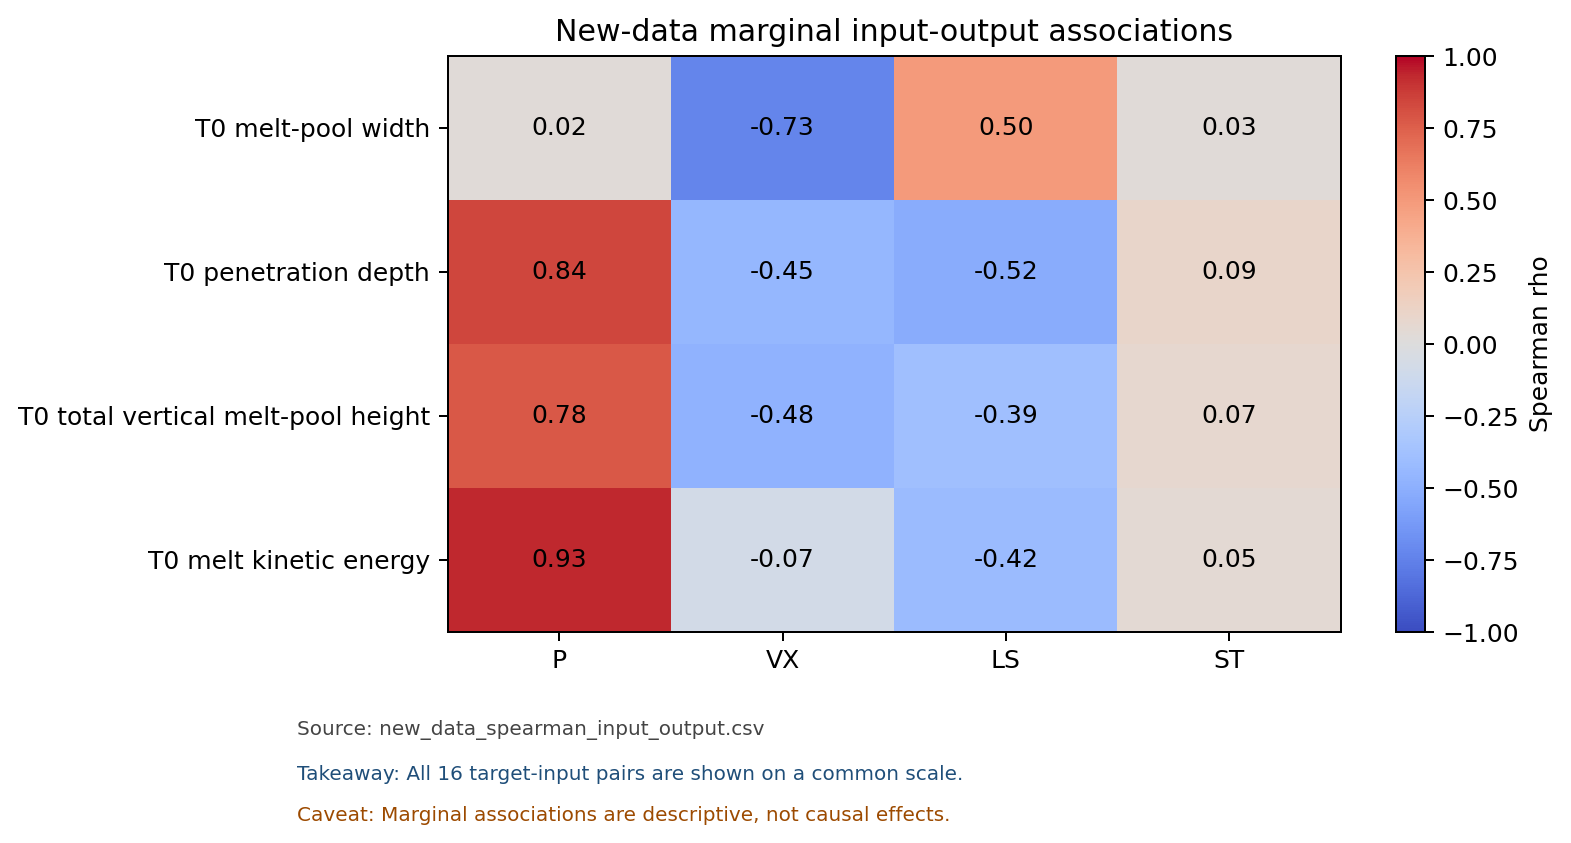

In [5]:
population = pd.read_csv(OUT / "model_ready_population_reference.csv")
spearman = pd.read_csv(OUT / "new_data_spearman_input_output.csv")
feature_columns = {"P": "P_W", "VX": "VX_m_per_s", "LS": "LS_um", "ST": "ST_K"}
target_columns = {
    "width": "T0_width_um", "depth": "T0_depth_um",
    "total_height": "T0_total_height_um", "kinetic_energy": "T0_kinetic_energy_nJ",
}
recomputed_rho = []
for target, target_column in target_columns.items():
    eligible = population[population[f"{target}_model_eligible"].astype(bool)]
    for input_name, input_column in feature_columns.items():
        rho, p_value = spearmanr(eligible[input_column], eligible[target_column])
        recomputed_rho.append({"target": target, "input": input_name, "recomputed_rho": rho, "recomputed_p": p_value})
spearman_reconciliation = spearman.merge(pd.DataFrame(recomputed_rho), on=["target", "input"])
spearman_reconciliation["absolute_rho_difference"] = (
    spearman_reconciliation["spearman_rho"] - spearman_reconciliation["recomputed_rho"]
).abs()
display(spearman_reconciliation.assign(absolute_rho=spearman_reconciliation["spearman_rho"].abs()).sort_values("absolute_rho", ascending=False).reset_index(drop=True))
print("maximum raw-table rho reconciliation difference:", spearman_reconciliation["absolute_rho_difference"].max())
display(Image(filename=str(OUT / "figures" / "01_new_data_spearman_heatmap.png")))

**What did we observe?** Power has the strongest positive marginal association with kinetic energy, depth, and total height; scan speed has the strongest negative width association.

**What does it mean?** These are marginal associations in the sampled new-data design, not causal effects.

**Did Week 6 reproduce?** Depth retains P-positive (rho=0.838) and VX-negative (rho=-0.445) directions.

**What remains uncertain?** Correlated design inputs can make a marginal association differ from the conditional Ridge or local GP view.


## 6. Standardized Ridge coefficients

**What are we doing?** We inspect Week 6-style standardized multivariable Ridge coefficients and fixed-specification bootstrap intervals.

**Why?** This gives a conditional linear association view after jointly accounting for P, VX, LS, and ST.

**What question does it answer?** Do coefficient signs and relative magnitudes agree with the marginal pattern?

**What would be suspicious?** Unstandardized inputs, a different alpha protocol, or causal-constant interpretation.


,target,target_label,target_unit,input,input_unit,standardized_coefficient,sign,absolute_magnitude,ci_low,ci_high,...,bootstrap_resamples,bootstrap_seed,selected_alpha,five_fold_cv_standardized_rmse,simulation_count,x_standardized,y_standardized,interpretation,recomputed_coefficient,absolute_coefficient_difference
4,depth,T0 penetration depth,um,P,W,0.548705,positive,0.548705,0.464803,0.632132,...,2000,3124812361,1.0,0.594022,164,True,True,conditional linear association; not a causal p...,0.548705,0.000000e+00
5,depth,T0 penetration depth,um,VX,m/s,-0.450822,negative,0.450822,-0.537030,-0.366708,...,2000,3124812361,1.0,0.594022,164,True,True,conditional linear association; not a causal p...,-0.450822,0.000000e+00
6,depth,T0 penetration depth,um,LS,um,-0.213302,negative,0.213302,-0.299260,-0.132670,...,2000,3124812361,1.0,0.594022,164,True,True,conditional linear association; not a causal p...,-0.213302,0.000000e+00
7,depth,T0 penetration depth,um,ST,K,-0.004243,negative,0.004243,-0.093168,0.087751,...,2000,3124812361,1.0,0.594022,164,True,True,conditional linear association; not a causal p...,-0.004243,4.423545e-17
12,kinetic_energy,T0 melt kinetic energy,nJ,P,W,0.943450,positive,0.943450,0.897266,0.996475,...,2000,1019548261,1.0,0.441498,164,True,True,conditional linear association; not a causal p...,0.943450,1.110223e-16
13,kinetic_energy,T0 melt kinetic energy,nJ,VX,m/s,-0.126241,negative,0.126241,-0.195488,-0.055061,...,2000,1019548261,1.0,0.441498,164,True,True,conditional linear association; not a causal p...,-0.126241,5.551115e-17
14,kinetic_energy,T0 melt kinetic energy,nJ,LS,um,0.100832,positive,0.100832,0.041531,0.164726,...,2000,1019548261,1.0,0.441498,164,True,True,conditional linear association; not a causal p...,0.100832,6.938894e-17
15,kinetic_energy,T0 melt kinetic energy,nJ,ST,K,-0.002046,negative,0.002046,-0.074156,0.062395,...,2000,1019548261,1.0,0.441498,164,True,True,conditional linear association; not a causal p...,-0.002046,5.811324e-17
8,total_height,T0 total vertical melt-pool height,um,P,W,0.544459,positive,0.544459,0.455019,0.635916,...,2000,2733701087,1.0,0.626937,164,True,True,conditional linear association; not a causal p...,0.544459,0.000000e+00
9,total_height,T0 total vertical melt-pool height,um,VX,m/s,-0.461471,negative,0.461471,-0.555685,-0.367625,...,2000,2733701087,1.0,0.626937,164,True,True,conditional linear association; not a causal p...,-0.461471,5.551115e-17


maximum fixed-specification coefficient reconciliation difference: 1.1102230246251565e-16


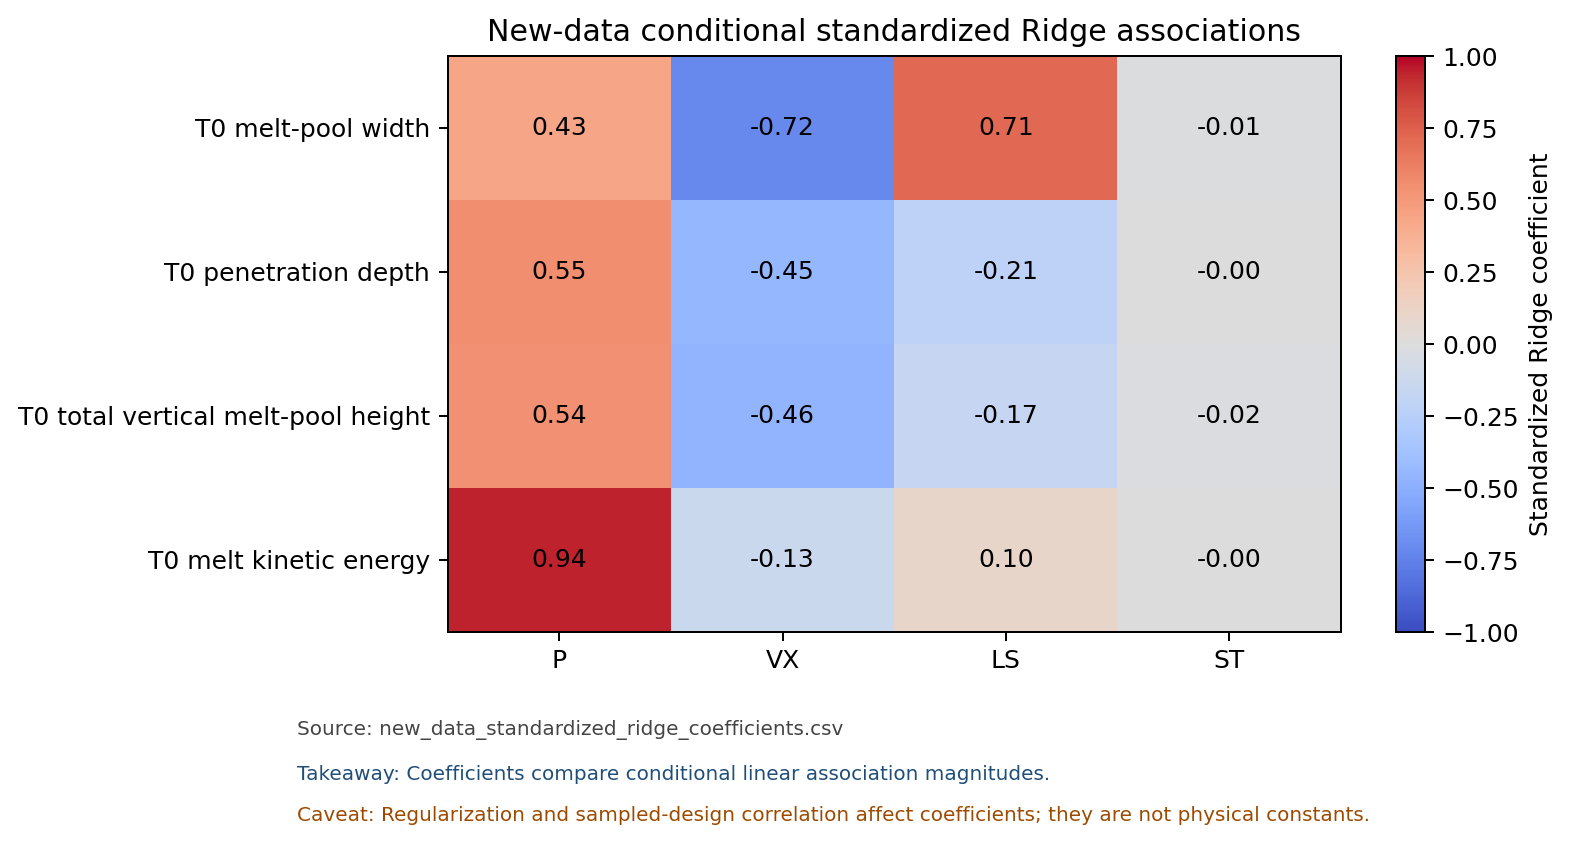

In [6]:
ridge = pd.read_csv(OUT / "new_data_standardized_ridge_coefficients.csv")
ridge_recomputed = []
for target, target_column in target_columns.items():
    eligible = population[population[f"{target}_model_eligible"].astype(bool)]
    x = StandardScaler().fit_transform(eligible[list(feature_columns.values())])
    y = StandardScaler().fit_transform(eligible[[target_column]]).ravel()
    alpha = float(ridge.loc[ridge["target"].eq(target), "selected_alpha"].iloc[0])
    coefficients = Ridge(alpha=alpha).fit(x, y).coef_
    ridge_recomputed.extend(
        {"target": target, "input": input_name, "recomputed_coefficient": coefficient}
        for input_name, coefficient in zip(feature_columns, coefficients)
    )
ridge_reconciliation = ridge.merge(pd.DataFrame(ridge_recomputed), on=["target", "input"])
ridge_reconciliation["absolute_coefficient_difference"] = (
    ridge_reconciliation["standardized_coefficient"] - ridge_reconciliation["recomputed_coefficient"]
).abs()
display(ridge_reconciliation.sort_values(["target", "absolute_magnitude"], ascending=[True, False]))
print("maximum fixed-specification coefficient reconciliation difference:", ridge_reconciliation["absolute_coefficient_difference"].max())
display(Image(filename=str(OUT / "figures" / "02_new_data_ridge_coefficients.png")))

**What did we observe?** Depth has positive P and negative VX/LS standardized coefficients, while the ST coefficient is close to zero in this sampled design.

**What does it mean?** The joint linear view agrees with the main depth direction while separating it from marginal input correlations.

**Did Week 6 reproduce?** The exact Week 6 scaling and Ridge alpha-selection workflow is retained.

**What remains uncertain?** A global linear coefficient cannot describe interactions or locally changing nonlinear response.


## 7. Week 6 versus new-data coefficient and correlation stability

**What are we doing?** We compare saved Week 6 Spearman and Ridge results with their new-data replications, then inspect three-view depth consensus.

**Why?** Agreement across historical and new designs is stronger evidence than a single new statistic.

**What question does it answer?** Which relationships preserve sign and which weaken, reverse, or remain unresolved?

**What would be suspicious?** Treating every numerical change as a scientific reversal or ignoring intervals that include zero.


In [7]:
spearman_compare = pd.read_csv(OUT / "week6_vs_new_data_spearman.csv")
ridge_compare = pd.read_csv(OUT / "week6_vs_new_data_standardized_coefficients.csv")
depth_consensus = pd.read_csv(OUT / "depth_feature_trend_consensus.csv")
display(spearman_compare)
display(ridge_compare)
display(depth_consensus)

,target,input,week6_spearman_rho,week6_simulation_count,week6_ci_low,week6_ci_high,new_data_spearman_rho,new_data_ci_low,new_data_ci_high,new_data_simulation_count,same_sign,new_data_ci_includes_zero,absolute_magnitude_change,comparison_status
0,width,P,0.503091,241,0.398467,0.594875,0.023922,-0.148642,0.199108,164,True,True,-0.479169,INCONCLUSIVE_CI_INCLUDES_ZERO
1,width,VX,-0.688674,241,-0.745507,-0.619040,-0.730336,-0.795828,-0.644484,164,True,False,0.041662,SAME_SIGN_SIMILAR
2,width,LS,0.469168,241,0.359154,0.570810,0.495545,0.354882,0.612447,164,True,False,0.026377,SAME_SIGN_SIMILAR
3,width,ST,0.199785,241,0.066837,0.327647,0.029731,-0.122496,0.188552,164,True,True,-0.170055,INCONCLUSIVE_CI_INCLUDES_ZERO
4,depth,P,0.788842,241,0.729098,0.832698,0.838238,0.774961,0.881850,164,True,False,0.049396,SAME_SIGN_SIMILAR
5,depth,VX,-0.437835,241,-0.525912,-0.339033,-0.445421,-0.548497,-0.324750,164,True,False,0.007585,SAME_SIGN_SIMILAR
6,depth,LS,-0.019216,241,-0.154086,0.115824,-0.518066,-0.617951,-0.389907,164,True,False,0.498851,SAME_SIGN_STRONGER
7,depth,ST,0.051461,241,-0.078057,0.180846,0.094174,-0.060662,0.257195,164,True,True,0.042713,INCONCLUSIVE_CI_INCLUDES_ZERO
8,kinetic_energy,P,0.968095,241,0.939876,0.982112,0.934820,0.893067,0.962500,164,True,False,-0.033276,SAME_SIGN_SIMILAR
9,kinetic_energy,VX,-0.015503,241,-0.133772,0.106333,-0.072537,-0.216010,0.076589,164,True,True,0.057034,INCONCLUSIVE_CI_INCLUDES_ZERO


,target,input,week6_standardized_coefficient,week6_simulation_count,week6_selected_alpha,new_data_standardized_coefficient,new_data_ci_low,new_data_ci_high,new_data_simulation_count,new_data_selected_alpha,same_sign,new_data_ci_includes_zero,absolute_magnitude_change,comparison_status
0,width,P,0.474987,241,0.000001,0.432672,0.369836,0.499851,164,1.0,True,False,-0.042315,SAME_SIGN_SIMILAR
1,width,VX,-0.748135,241,0.000001,-0.717857,-0.794414,-0.651026,164,1.0,True,False,-0.030279,SAME_SIGN_SIMILAR
2,width,LS,0.373058,241,0.000001,0.714249,0.645311,0.790573,164,1.0,True,False,0.341191,SAME_SIGN_STRONGER
3,width,ST,0.026220,241,0.000001,-0.011820,-0.055046,0.030235,164,1.0,False,True,-0.014400,INCONCLUSIVE_CI_INCLUDES_ZERO
4,depth,P,0.818718,241,1.000000,0.548705,0.464803,0.632132,164,1.0,True,False,-0.270012,SAME_SIGN_WEAKER
5,depth,VX,-0.499780,241,1.000000,-0.450822,-0.537030,-0.366708,164,1.0,True,False,-0.048958,SAME_SIGN_SIMILAR
6,depth,LS,-0.214166,241,1.000000,-0.213302,-0.299260,-0.132670,164,1.0,True,False,-0.000864,SAME_SIGN_SIMILAR
7,depth,ST,-0.048756,241,1.000000,-0.004243,-0.093168,0.087751,164,1.0,True,True,-0.044513,INCONCLUSIVE_CI_INCLUDES_ZERO
8,kinetic_energy,P,0.972567,241,0.000001,0.943450,0.897266,0.996475,164,1.0,True,False,-0.029117,SAME_SIGN_SIMILAR
9,kinetic_energy,VX,-0.094100,241,0.000001,-0.126241,-0.195488,-0.055061,164,1.0,True,False,0.032141,SAME_SIGN_SIMILAR


,input,week6_expected_sign,week6_standardized_ridge_coefficient,new_spearman_sign,new_spearman_rho,new_spearman_ci_low,new_spearman_ci_high,new_ridge_sign,new_standardized_ridge_coefficient,new_ridge_ci_low,new_ridge_ci_high,new_gp_sensitivity_sign,new_gp_median_standardized_local_sensitivity,new_gp_fraction_positive,new_gp_fraction_negative,agreement_count,opposite_count,trend_status
0,P,positive,0.818718,positive,0.838238,0.774961,0.881850,positive,0.548705,0.464803,0.632132,positive,0.303267,0.929936,0.070064,3,0,REPRODUCED
1,VX,negative,-0.499780,negative,-0.445421,-0.548497,-0.324750,negative,-0.450822,-0.537030,-0.366708,negative,-0.132355,0.237500,0.762500,3,0,REPRODUCED
2,LS,negative,-0.214166,negative,-0.518066,-0.617951,-0.389907,negative,-0.213302,-0.299260,-0.132670,mixed,-0.067451,0.283871,0.716129,2,0,WEAKENED
3,ST,negative,-0.048756,unresolved,0.094174,-0.060662,0.257195,unresolved,-0.004243,-0.093168,0.087751,mixed,-0.007716,0.451613,0.548387,0,0,UNRESOLVED


**What did we observe?** The P-positive and VX-negative depth relationships agree across Spearman, Ridge, and supported GP sensitivities; LS weakens and ST is unresolved for depth.

**What does it mean?** The large depth RMSE coexists with a stable broad response direction.

**Did Week 6 reproduce?** P and VX are classified REPRODUCED under the predeclared three-view consensus logic.

**What remains uncertain?** Agreement in sign does not imply uniform local magnitude or causal identification.


## 8. GP controlled response curves

**What are we doing?** We vary one input while holding others at medians, including multiple P profiles for the KE–LS curve.

**Why?** A nonlinear GP has no single global coefficient, so controlled curves reveal supported response shape.

**What question does it answer?** Do Week 6-style width–LS and KE–LS patterns persist on new data?

**What would be suspicious?** Far-range extrapolation, unsupported points presented as evidence, or performance claims from full-data fits.


,target,varying_input,profile,grid_points,supported_points
0,depth,LS,median_reference,101,100
1,depth,P,median_reference,101,101
2,depth,ST,median_reference,101,101
3,depth,VX,median_reference,101,101
4,kinetic_energy,LS,high_P_q90,101,75
5,kinetic_energy,LS,low_P_q10,101,101
6,kinetic_energy,LS,median_P_q50,101,100
7,kinetic_energy,P,median_reference,101,101
8,kinetic_energy,ST,median_reference,101,101
9,kinetic_energy,VX,median_reference,101,101


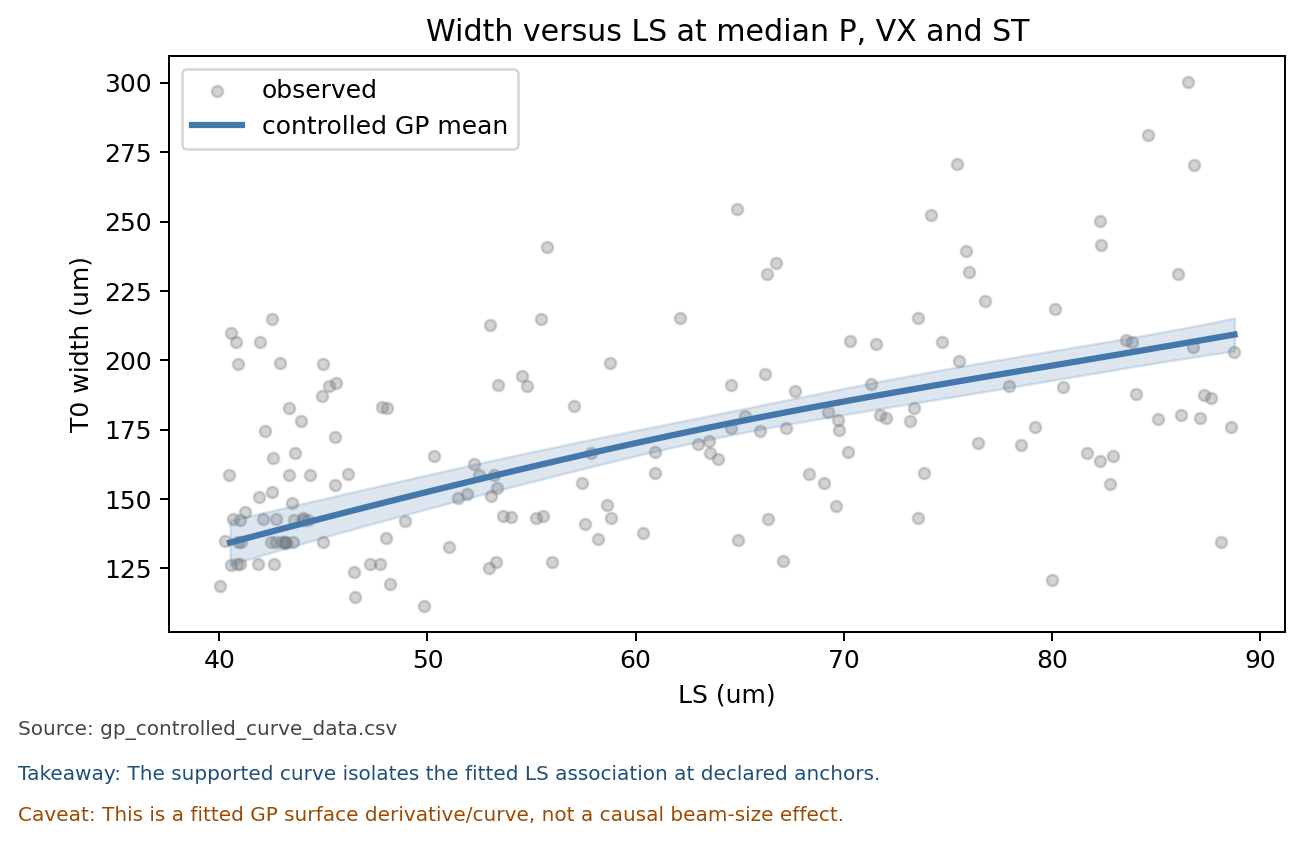

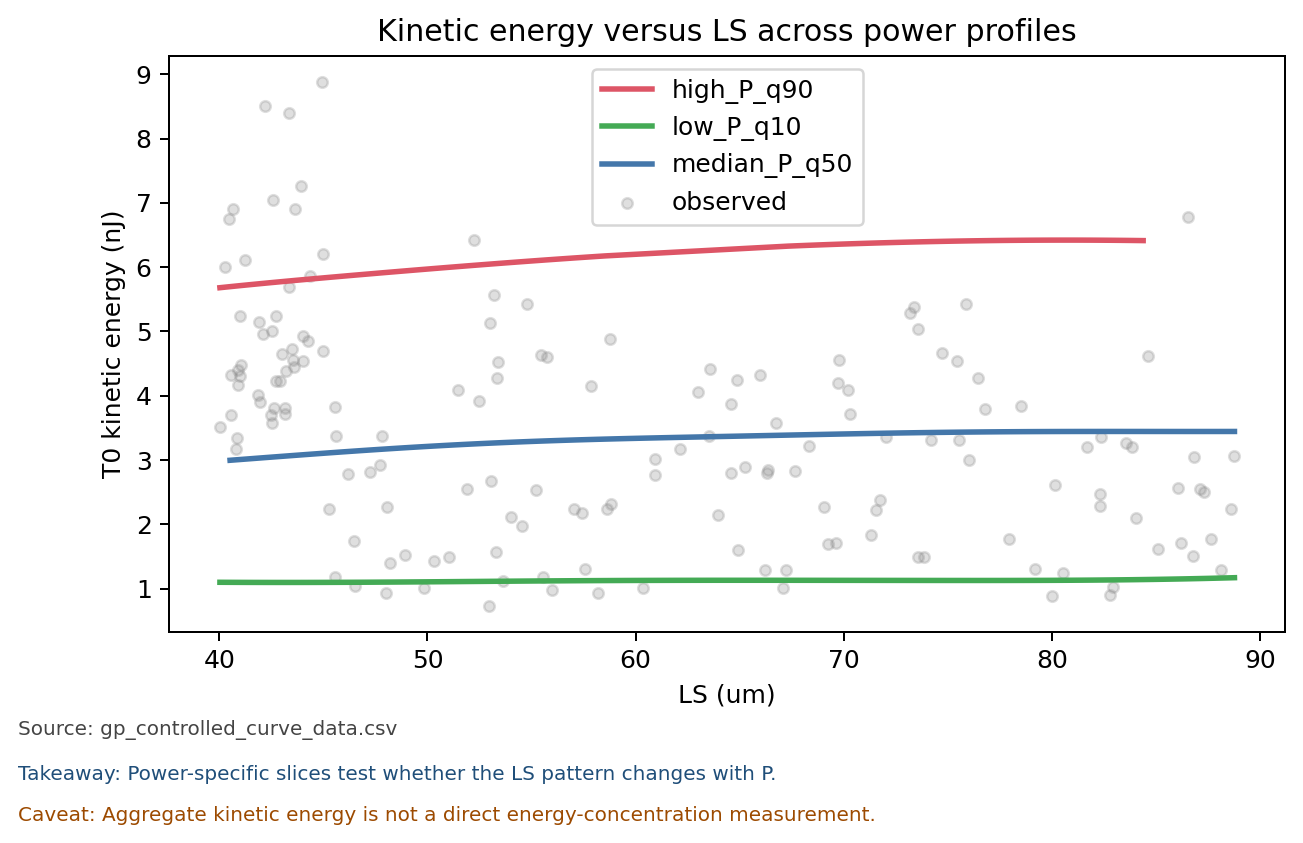

In [8]:
curves = pd.read_csv(OUT / "gp_controlled_curve_data.csv")
display(curves.groupby(["target", "varying_input", "profile"], dropna=False).agg(
    grid_points=("input_value", "size"), supported_points=("within_observed_support", "sum")
).reset_index())
display(Image(filename=str(OUT / "figures" / "03_width_vs_ls_controlled_curve.png")))
display(Image(filename=str(OUT / "figures" / "04_kinetic_energy_ls_power_profiles.png")))

**What did we observe?** Width rises with LS over supported portions of the median-anchored curve; KE–LS shape remains dependent on the power profile rather than uniformly decreasing.

**What does it mean?** Interaction-aware curves prevent a misleading single global KE–LS claim.

**Did Week 6 reproduce?** The width–LS relationship reproduces; the qualified Week 6 KE–LS statement remains mixed but not reversed into a universal rule.

**What remains uncertain?** These are fitted-surface summaries conditional on chosen anchors and observed support.


## 9. GP standardized local sensitivities

**What are we doing?** We summarize guarded central finite differences of the full-data GP mean in standardized units.

**Why?** This is a local nonlinear analogue of a standardized coefficient.

**What question does it answer?** Are depth sensitivities consistently P-positive and VX-negative at observed points?

**What would be suspicious?** One-sided out-of-range derivatives, unsupported finite differences, or calling model-surface derivatives true causal physics.


,target,target_label,input,model_configuration,median_standardized_local_sensitivity,q25_standardized_local_sensitivity,q75_standardized_local_sensitivity,iqr_standardized_local_sensitivity,fraction_positive,fraction_negative,valid_supported_evaluations,population_size,finite_difference_step_fraction_input_sd,interpretation,causal_claim,recomputed_median,recomputed_q25,recomputed_q75,recomputed_n
0,width,T0 melt-pool width,P,matern32_learned_nugget,0.462131,0.255643,0.731595,0.475952,1.000000,0.000000,157,164,0.05,predicted target SD per one input SD on fitted...,False,0.462131,0.255643,0.731595,157
1,width,T0 melt-pool width,VX,matern32_learned_nugget,-0.666785,-1.014193,-0.409734,0.604459,0.000000,1.000000,160,164,0.05,predicted target SD per one input SD on fitted...,False,-0.666785,-1.014193,-0.409734,160
2,width,T0 melt-pool width,LS,matern32_learned_nugget,0.670815,0.496176,0.909307,0.413130,1.000000,0.000000,155,164,0.05,predicted target SD per one input SD on fitted...,False,0.670815,0.496176,0.909307,155
3,width,T0 melt-pool width,ST,matern32_learned_nugget,0.002515,-0.031433,0.047321,0.078753,0.516129,0.483871,155,164,0.05,predicted target SD per one input SD on fitted...,False,0.002515,-0.031433,0.047321,155
4,depth,T0 penetration depth,P,matern32_no_nugget,0.303267,0.174749,0.477607,0.302858,0.929936,0.070064,157,164,0.05,predicted target SD per one input SD on fitted...,False,0.303267,0.174749,0.477607,157
5,depth,T0 penetration depth,VX,matern32_no_nugget,-0.132355,-0.395923,-0.009696,0.386226,0.237500,0.762500,160,164,0.05,predicted target SD per one input SD on fitted...,False,-0.132355,-0.395923,-0.009696,160
6,depth,T0 penetration depth,LS,matern32_no_nugget,-0.067451,-0.286336,0.002681,0.289017,0.283871,0.716129,155,164,0.05,predicted target SD per one input SD on fitted...,False,-0.067451,-0.286336,0.002681,155
7,depth,T0 penetration depth,ST,matern32_no_nugget,-0.007716,-0.109233,0.064743,0.173976,0.451613,0.548387,155,164,0.05,predicted target SD per one input SD on fitted...,False,-0.007716,-0.109233,0.064743,155
8,total_height,T0 total vertical melt-pool height,P,matern32_no_nugget,0.324995,0.182423,0.478546,0.296123,0.929936,0.070064,157,164,0.05,predicted target SD per one input SD on fitted...,False,0.324995,0.182423,0.478546,157
9,total_height,T0 total vertical melt-pool height,VX,matern32_no_nugget,-0.154801,-0.412359,0.010616,0.422976,0.268750,0.731250,160,164,0.05,predicted target SD per one input SD on fitted...,False,-0.154801,-0.412359,0.010616,160


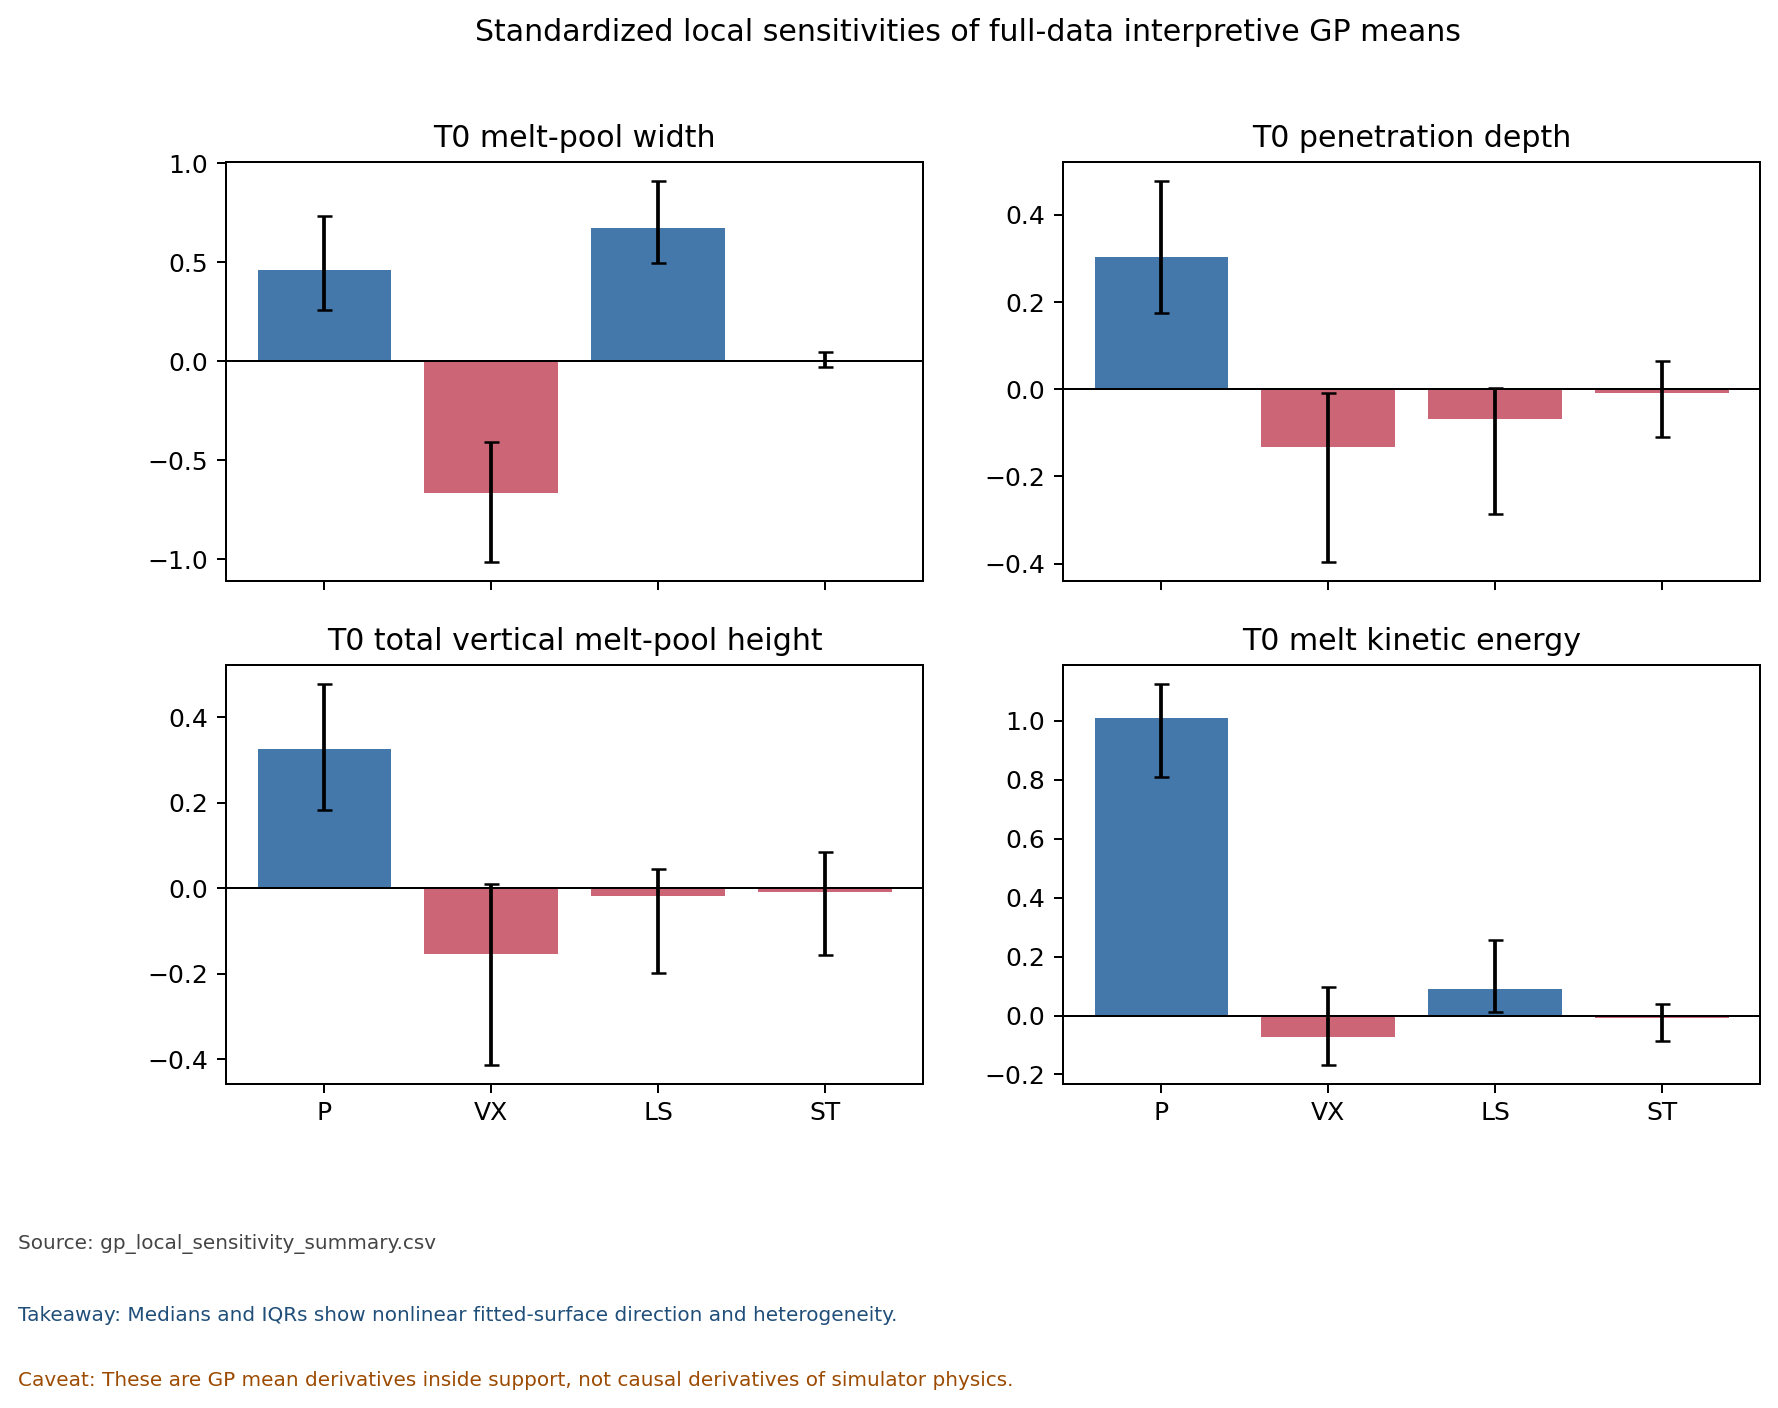

In [9]:
sensitivity = pd.read_csv(OUT / "gp_local_sensitivity_summary.csv")
sensitivity_values = pd.read_csv(OUT / "gp_local_sensitivity_values.csv")
valid_sensitivity = sensitivity_values[sensitivity_values["valid_supported_evaluation"].astype(bool)]
recomputed_sensitivity = valid_sensitivity.groupby(["target", "input"])["standardized_local_sensitivity"].agg(
    recomputed_median="median", recomputed_q25=lambda values: values.quantile(0.25),
    recomputed_q75=lambda values: values.quantile(0.75), recomputed_n="size",
).reset_index()
sensitivity_reconciliation = sensitivity.merge(recomputed_sensitivity, on=["target", "input"])
display(sensitivity_reconciliation)
display(Image(filename=str(OUT / "figures" / "05_gp_local_sensitivity_summary.png")))

**What did we observe?** Median standardized depth sensitivities are P=0.303 and VX=-0.132, with guarded evaluation counts reported.

**What does it mean?** The fitted nonlinear surface supports the same broad depth directions as Spearman and Ridge.

**Did Week 6 reproduce?** P-positive and VX-negative depth effects reproduce across the third independent view.

**What remains uncertain?** Local sensitivity distributions can still contain heterogeneity and are conditional on this fitted GP surface.


## 10. Depth and total-height P–VX surfaces

**What are we doing?** We inspect P–VX response surfaces at median LS and ST with convex-hull and 4D-neighbour support masks.

**Why?** The surfaces visualize nonlinear interactions while marking regions where the design gives weak support.

**What question does it answer?** Do depth and total height rise with P and fall with VX inside supported regions?

**What would be suspicious?** Smooth color outside observed support being presented as measured behaviour.


,target,diagnostic,varying_inputs,profile,grid_count,supported_grid_count,supported_fraction,support_distance_threshold,model_configuration,reference_LS,reference_ST
0,width,controlled_curve,P,median_reference,101,101,1.000000,1.183771,matern32_learned_nugget,NaN,NaN
1,width,controlled_curve,VX,median_reference,101,101,1.000000,1.183771,matern32_learned_nugget,NaN,NaN
2,width,controlled_curve,LS,median_reference,101,100,0.990099,1.183771,matern32_learned_nugget,NaN,NaN
3,width,controlled_curve,ST,median_reference,101,101,1.000000,1.183771,matern32_learned_nugget,NaN,NaN
4,depth,controlled_curve,P,median_reference,101,101,1.000000,1.183771,matern32_no_nugget,NaN,NaN
5,depth,controlled_curve,VX,median_reference,101,101,1.000000,1.183771,matern32_no_nugget,NaN,NaN
6,depth,controlled_curve,LS,median_reference,101,100,0.990099,1.183771,matern32_no_nugget,NaN,NaN
7,depth,controlled_curve,ST,median_reference,101,101,1.000000,1.183771,matern32_no_nugget,NaN,NaN
8,total_height,controlled_curve,P,median_reference,101,101,1.000000,1.183771,matern32_no_nugget,NaN,NaN
9,total_height,controlled_curve,VX,median_reference,101,101,1.000000,1.183771,matern32_no_nugget,NaN,NaN


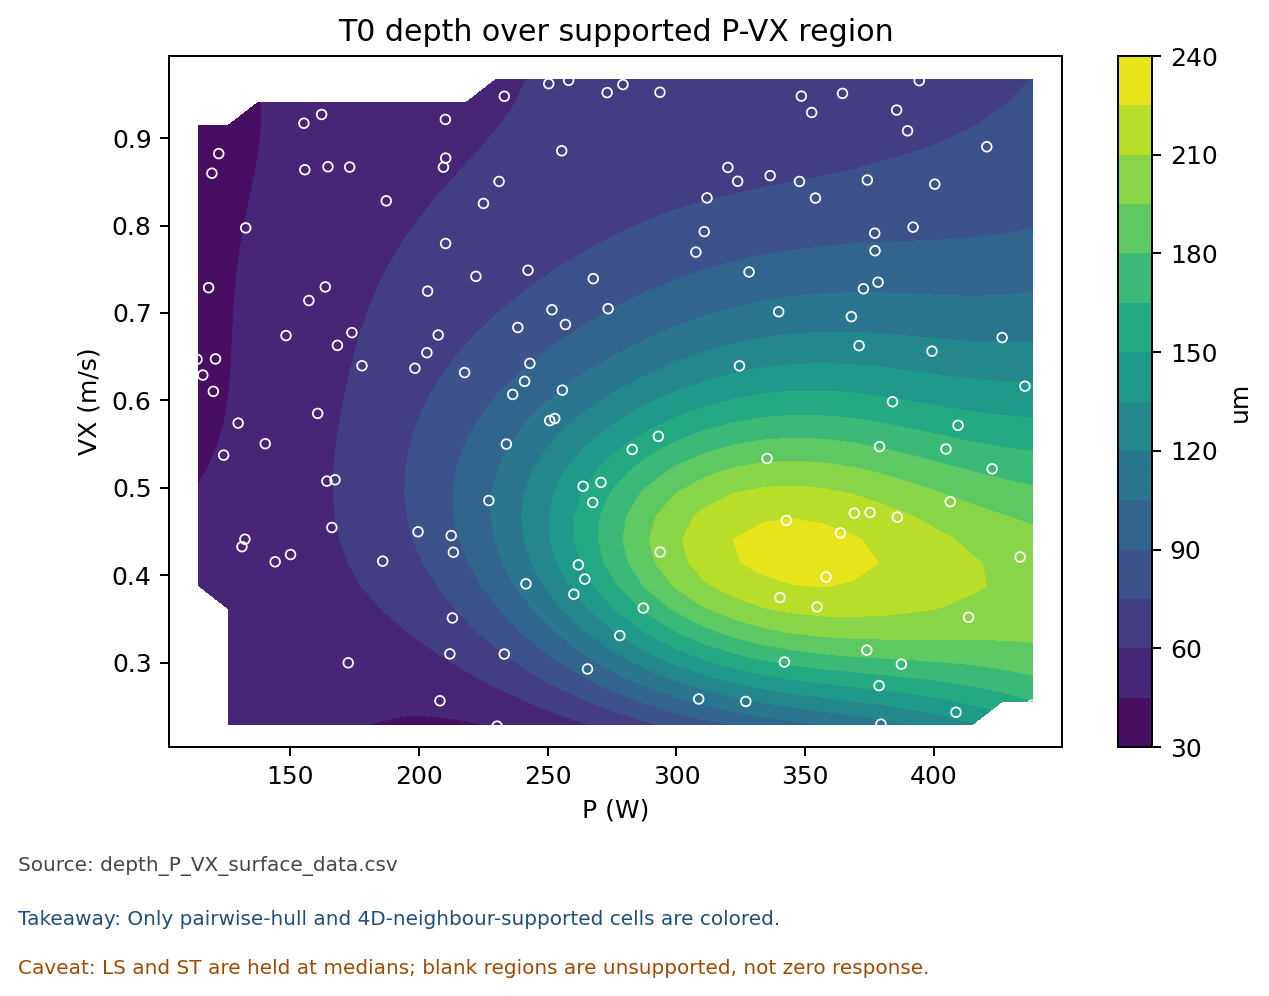

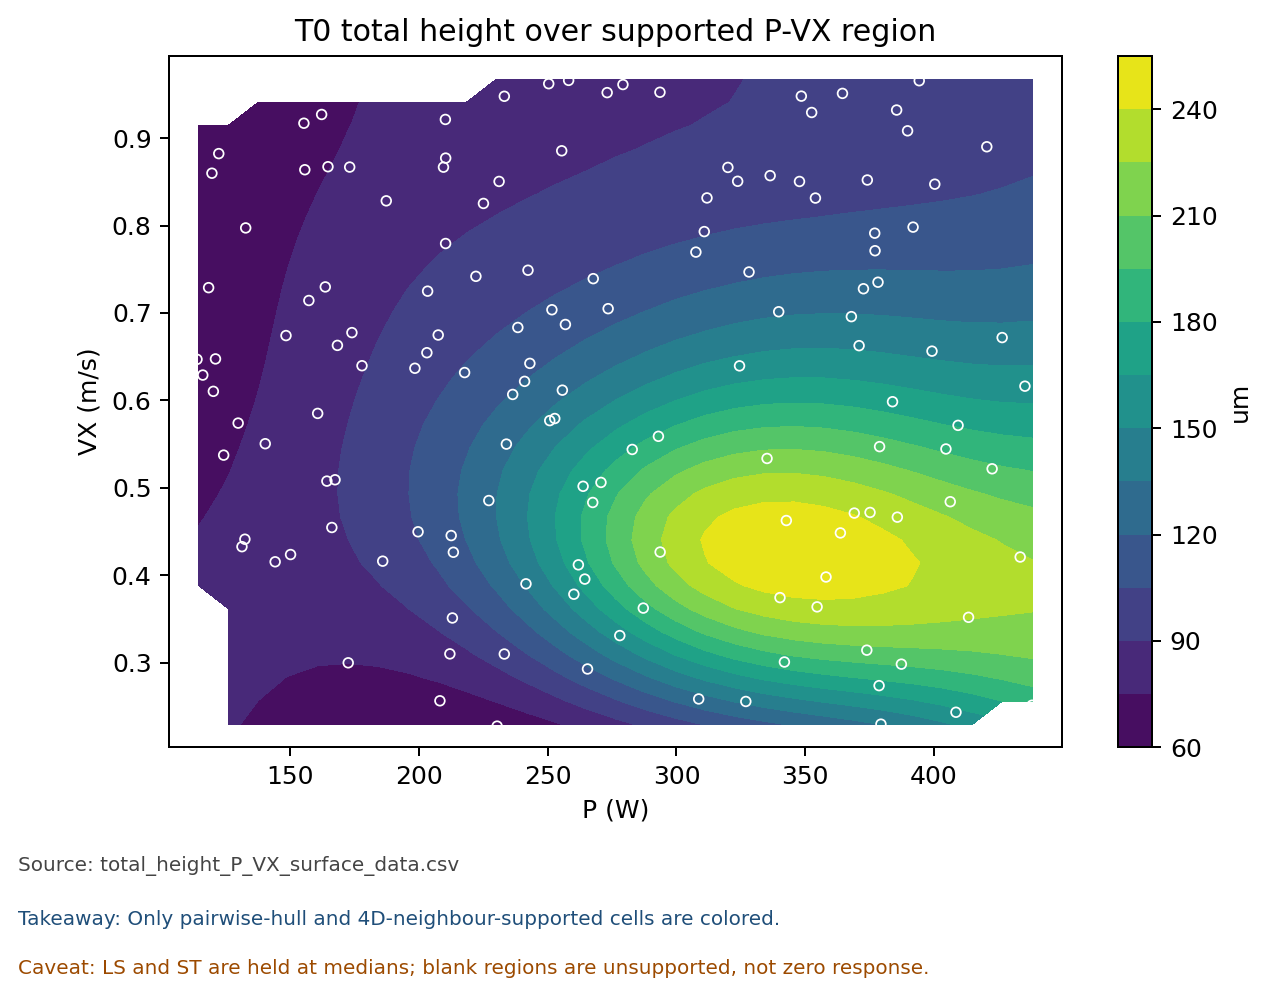

In [10]:
support = pd.read_csv(OUT / "gp_observed_support_summary.csv")
display(support)
display(Image(filename=str(OUT / "figures" / "06_depth_P_VX_surface.png")))
display(Image(filename=str(OUT / "figures" / "07_total_height_P_VX_surface.png")))

**What did we observe?** Supported surface regions show the broad P-positive/VX-negative pattern for depth and total height, with unsupported grid cells visibly masked.

**What does it mean?** The interaction pattern is compatible with Week 6 without claiming values in uncovered regions.

**Did Week 6 reproduce?** P–VX structure for depth and total height is classified REPRODUCED.

**What remains uncertain?** Surface shape depends on median LS/ST anchors and the retained Matérn 3/2 interpretability fit.


## 11. Depth LOO error distribution and concentration

**What are we doing?** We reuse fixed Phase 3 LOO predictions for three Matérn configurations and quantify the heavy-error tail.

**Why?** RMSE can be dominated by a small number of simulations; concentration must be measured before changing models.

**What question does it answer?** Is poor depth performance broad or tail dominated?

**What would be suspicious?** In-sample residuals, case removal, or trimmed RMSE replacing the full metric.


,model,model_label,simulation_count,MAE,RMSE,median_absolute_error,q75_absolute_error,q90_absolute_error,q95_absolute_error,maximum_absolute_error,residual_source,in_sample_residual
0,matern32_no_nugget,"Matérn 3/2, numerical jitter",164,11.863614,21.068070,4.645136,13.686006,32.708081,46.327087,121.566152,Phase 3 exact LOO held-out predictions,False
1,matern32_learned_nugget,Matérn 3/2 + learned nugget,164,11.937466,21.808185,4.474705,13.665107,32.888510,51.147358,122.115493,Phase 3 exact LOO held-out predictions,False
2,matern52_no_nugget,"Matérn 5/2, numerical jitter",164,12.635219,21.064829,5.805049,15.244932,33.653893,47.160757,118.501146,Phase 3 exact LOO held-out predictions,False


,model,model_label,worst_simulation_count,squared_error_contribution,total_squared_error,fraction_total_squared_error,percent_total_squared_error,diagnostic_only,recomputed_fraction,absolute_difference
0,matern32_learned_nugget,Matérn 3/2 + learned nugget,1,14912.193711,77997.89902,0.191187,19.118712,True,0.191187,0.000000e+00
1,matern32_learned_nugget,Matérn 3/2 + learned nugget,3,28004.838878,77997.89902,0.359046,35.904607,True,0.359046,5.551115e-17
2,matern32_learned_nugget,Matérn 3/2 + learned nugget,5,37623.720024,77997.89902,0.482368,48.236838,True,0.482368,5.551115e-17
3,matern32_learned_nugget,Matérn 3/2 + learned nugget,10,52899.721468,77997.89902,0.678220,67.821983,True,0.678220,0.000000e+00
4,matern32_learned_nugget,Matérn 3/2 + learned nugget,20,66300.587679,77997.89902,0.850030,85.003043,True,0.850030,0.000000e+00


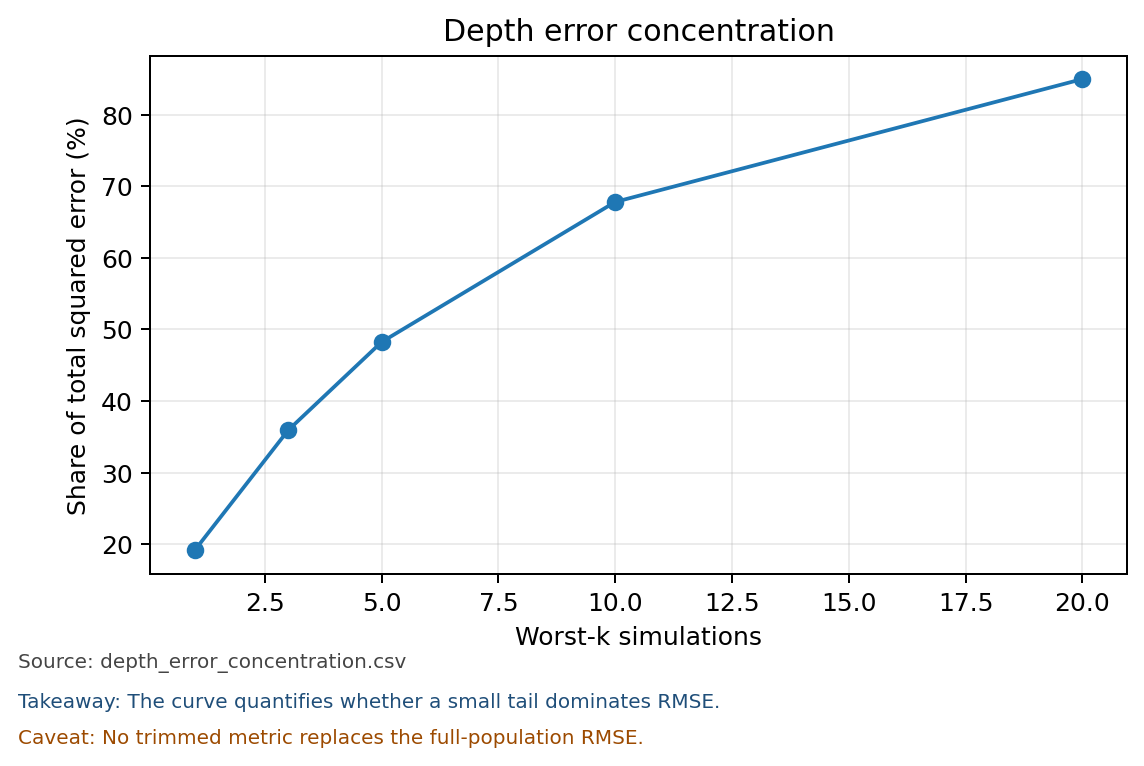

In [11]:
error_distribution = pd.read_csv(OUT / "depth_error_distribution.csv")
concentration = pd.read_csv(OUT / "depth_error_concentration.csv")
hard_cases = pd.read_csv(OUT / "depth_consensus_hard_cases.csv")
primary_squared_error = hard_cases["squared_error__matern32_learned_nugget"].sort_values(ascending=False)
recomputed_concentration = pd.DataFrame({
    "worst_simulation_count": [1, 3, 5, 10, 20],
    "recomputed_fraction": [primary_squared_error.head(k).sum() / primary_squared_error.sum() for k in [1, 3, 5, 10, 20]],
})
stored_primary_concentration = concentration[concentration["model"].eq("matern32_learned_nugget")]
concentration_reconciliation = stored_primary_concentration.merge(recomputed_concentration, on="worst_simulation_count")
concentration_reconciliation["absolute_difference"] = (
    concentration_reconciliation["fraction_total_squared_error"] - concentration_reconciliation["recomputed_fraction"]
).abs()
display(error_distribution)
display(concentration_reconciliation)
display(Image(filename=str(OUT / "figures" / "09_depth_error_concentration.png")))

**What did we observe?** For the primary depth model, the worst 1/3/5/10 simulations contribute 19.1%/35.9%/48.2%/67.8% of total squared error.

**What does it mean?** Depth error has a substantial heavy tail, but no difficult simulation is removed from reported metrics.

**Did Week 6 reproduce?** This is a new Phase 4 diagnosis, not a Week 6 effect replication.

**What remains uncertain?** Heavy-tail concentration alone does not distinguish regime mixture from target-quality or model-family problems.


## 12. Depth error versus observed depth

**What are we doing?** We relate signed and absolute LOO residuals to observed depth and summarize quantile-based depth bins.

**Why?** High-depth cases may be disproportionately difficult even if the broad P/VX trend is correct.

**What question does it answer?** Are errors concentrated in the high-depth tail or distributed across scales?

**What would be suspicious?** Bins chosen after inspecting outcomes or a high-depth association mistaken for proof of measurement error.


,grouping,group,model,n,MAE,RMSE,median_absolute_error,q75_absolute_error,q90_absolute_error,q95_absolute_error,maximum_absolute_error,observed_depth_min_um,observed_depth_max_um
0,observed_depth_quantile,Q1_shallow,matern32_no_nugget,41,4.647362,8.466408,3.295683,5.383698,8.496321,10.074104,45.219904,26.909320,58.74257
1,observed_depth_quantile,Q2,matern32_no_nugget,41,5.166178,9.511410,2.342159,4.298136,16.513705,19.947461,43.265558,58.764745,74.73733
2,observed_depth_quantile,Q3,matern32_no_nugget,41,12.632290,19.905870,6.731317,13.491847,35.239222,46.522473,63.418356,74.745610,100.24090
3,observed_depth_quantile,Q4_deep,matern32_no_nugget,41,25.008626,34.886439,17.167580,32.159451,61.305260,68.324936,121.566152,102.247700,300.52990
4,observed_depth_quantile,Q1_shallow,matern32_learned_nugget,41,4.357058,9.662548,2.734989,4.123402,6.828709,8.985544,56.608978,26.909320,58.74257
5,observed_depth_quantile,Q2,matern32_learned_nugget,41,5.055336,9.516905,2.592425,4.003030,15.795260,20.506359,43.602584,58.764745,74.73733
6,observed_depth_quantile,Q3,matern32_learned_nugget,41,13.481725,22.958256,6.176529,14.490766,35.431759,43.816601,82.515120,74.745610,100.24090
7,observed_depth_quantile,Q4_deep,matern32_learned_nugget,41,24.855745,34.516227,17.138596,31.341579,60.196273,64.264308,122.115493,102.247700,300.52990
8,observed_depth_quantile,Q1_shallow,matern52_no_nugget,41,5.980870,8.220402,4.333911,7.063995,13.871197,17.325419,24.661913,26.909320,58.74257
9,observed_depth_quantile,Q2,matern52_no_nugget,41,5.792121,9.828566,3.526787,5.543862,18.121113,21.108588,42.170597,58.764745,74.73733


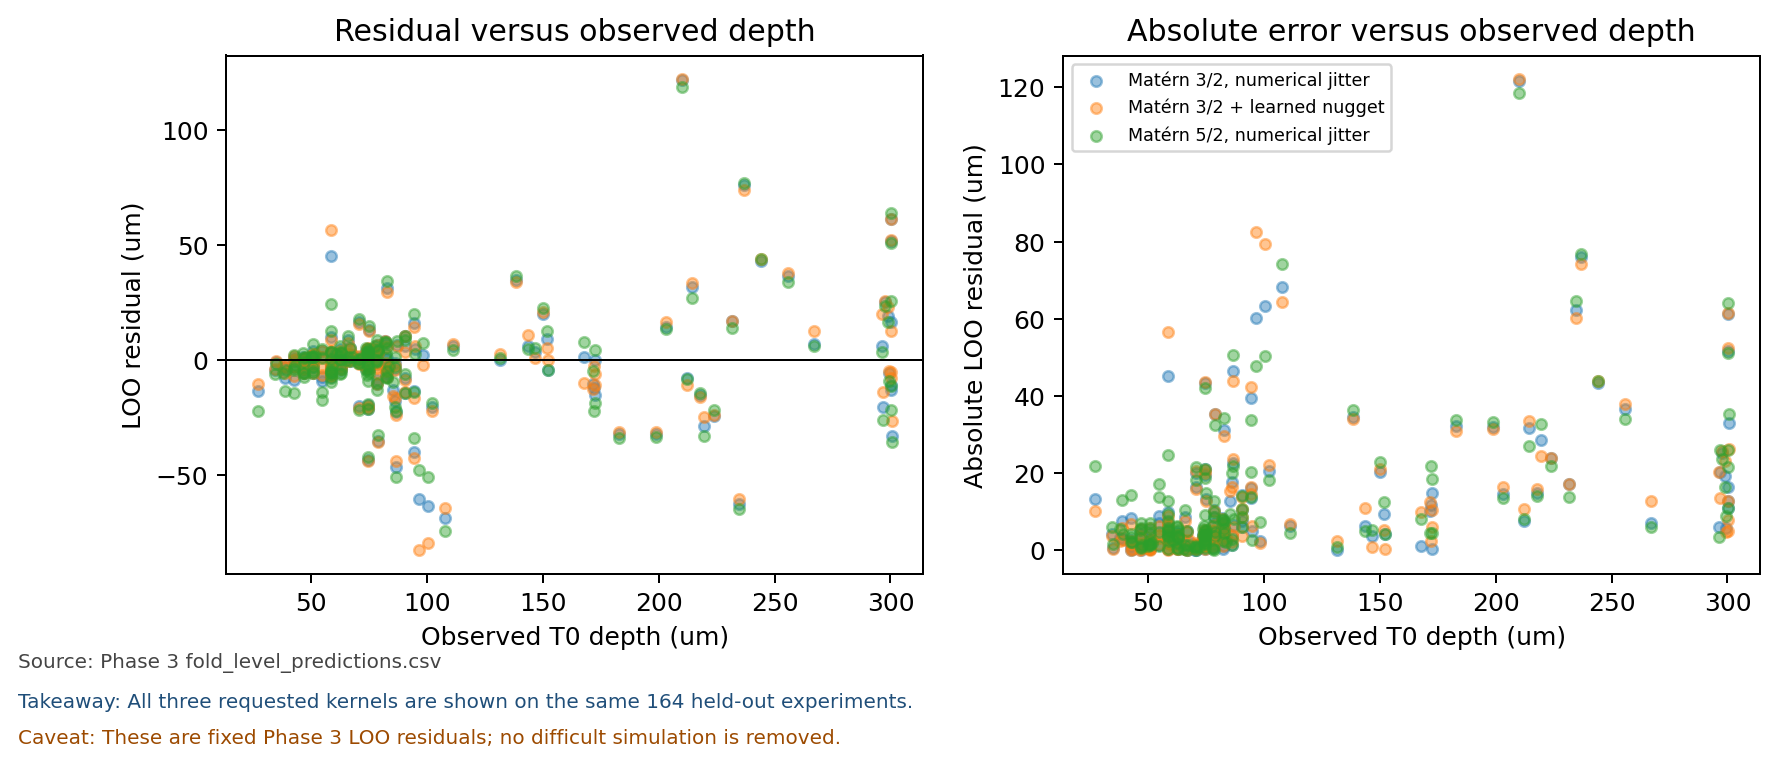

In [12]:
by_depth = pd.read_csv(OUT / "depth_error_by_observed_depth.csv")
display(by_depth)
display(Image(filename=str(OUT / "figures" / "08_depth_error_vs_observed_depth.png")))

**What did we observe?** Absolute error rises with observed depth, while the largest misses form a smaller heavy-error subgroup rather than uniform failure across all rows.

**What does it mean?** High penetration is an important descriptor of difficulty, not a reason to discard simulations.

**Did Week 6 reproduce?** The positive P–depth trend remains visible despite larger errors at the high-depth end.

**What remains uncertain?** Depth scale can co-vary with Keyhole context, local heterogeneity, and extraction-quality diagnostics.


## 13. Depth error versus Keyhole context

**What are we doing?** We compare fixed LOO errors across existing Phase 1 Keyhole presence and timing contexts.

**Why?** Regime-rich simulations may be overrepresented among hard depth cases.

**What question does it answer?** Are catastrophic errors enriched among Keyhole-positive or timing-specific groups?

**What would be suspicious?** Building a classifier, changing labels, or claiming Keyhole causes prediction error.


,grouping,group,model,n,MAE,RMSE,median_absolute_error,q75_absolute_error,q90_absolute_error,q95_absolute_error,maximum_absolute_error,difference_estimate,difference_ci_low,difference_ci_high,bootstrap_resamples,causal_claim
0,has_keyhole,False,matern32_learned_nugget,101,5.303819,9.787691,2.792561,5.365902,10.621743,19.935347,56.608978,NaN,NaN,NaN,NaN,NaN
1,has_keyhole,True,matern32_learned_nugget,63,22.572361,32.931437,14.490766,31.201897,58.642893,73.105315,122.115493,NaN,NaN,NaN,NaN,NaN
2,keyhole_timing_relative_to_T0,before_T0,matern32_learned_nugget,22,12.287083,17.739333,6.784326,16.182512,34.104645,41.924412,43.602584,NaN,NaN,NaN,NaN,NaN
3,keyhole_timing_relative_to_T0,no_Keyhole,matern32_learned_nugget,101,5.303819,9.787691,2.792561,5.365902,10.621743,19.935347,56.608978,NaN,NaN,NaN,NaN,NaN
4,keyhole_timing_relative_to_T0,spans_multiple_T0_regions,matern32_learned_nugget,41,28.091290,38.698070,20.254644,33.964367,64.264308,79.271055,122.115493,NaN,NaN,NaN,NaN,NaN
5,keyhole_transient_by_sequence,False,matern32_learned_nugget,33,28.141374,37.760571,21.042636,33.964367,61.181078,68.193645,122.115493,NaN,NaN,NaN,NaN,NaN
6,keyhole_transient_by_sequence,True,matern32_learned_nugget,30,16.446446,26.626308,7.088884,19.712468,42.399776,63.220243,82.515120,NaN,NaN,NaN,NaN,NaN
7,keyhole_persistent_to_last_physical_frame,False,matern32_learned_nugget,30,16.446446,26.626308,7.088884,19.712468,42.399776,63.220243,82.515120,NaN,NaN,NaN,NaN,NaN
8,keyhole_persistent_to_last_physical_frame,True,matern32_learned_nugget,33,28.141374,37.760571,21.042636,33.964367,61.181078,68.193645,122.115493,NaN,NaN,NaN,NaN,NaN
9,keyhole_frame_count_quantile,"(1.999, 32.0]",matern32_learned_nugget,16,18.214259,28.528085,6.217060,25.478404,42.934357,53.330718,82.515120,NaN,NaN,NaN,NaN,NaN


,has_keyhole,recomputed_n,recomputed_MAE,recomputed_RMSE
0,False,101,5.303819,9.787691
1,True,63,22.572361,32.931437


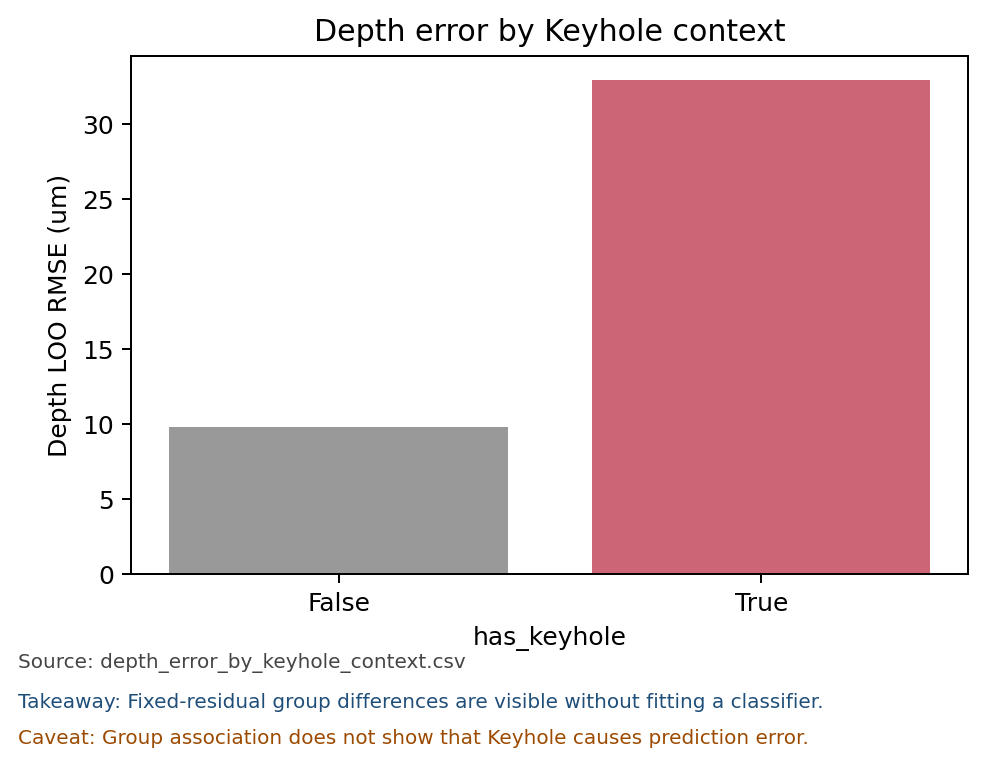

In [13]:
keyhole = pd.read_csv(OUT / "depth_error_by_keyhole_context.csv")
primary_abs = "absolute_residual__matern32_learned_nugget"
keyhole_recomputed = hard_cases.groupby("has_keyhole").agg(
    recomputed_n=(primary_abs, "size"),
    recomputed_MAE=(primary_abs, "mean"),
    recomputed_RMSE=("squared_error__matern32_learned_nugget", lambda values: np.sqrt(values.mean())),
).reset_index()
display(keyhole)
display(keyhole_recomputed)
display(Image(filename=str(OUT / "figures" / "10_depth_error_keyhole_context.png")))

**What did we observe?** Keyhole-positive simulations have materially larger aggregate depth error, with timing groups reported descriptively.

**What does it mean?** Keyhole context is an enrichment signal compatible with regime mixture; it is not causal evidence.

**Did Week 6 reproduce?** This diagnostic helps explain why a stable average P/VX trend can coexist with hard local cases.

**What remains uncertain?** Group overlap, sparse subgroups, and correlated depth scale limit isolated interpretation.


## 14. Depth error versus input-space sparsity and local heterogeneity

**What are we doing?** We compare absolute LOO error with standardized 4D neighbour distance and nearby observed-depth variation.

**Why?** This separates simple lack of local design support from locally varying response structure.

**What question does it answer?** Do hard cases occur because they are isolated, or because nearby inputs have sharply different depths?

**What would be suspicious?** Calling neighbour variation a discontinuity without evidence or using old-data points as Phase 3 support.


,diagnostic,spearman_rho_with_absolute_depth_error,p_value,simulation_count,input_space_uses_new_data_only,self_excluded,causal_claim
0,nearest_neighbor_distance_standardized,0.047214,5.482809e-01,164,True,True,False
1,median_3nn_distance_standardized,0.081641,2.986851e-01,164,True,True,False
2,median_5nn_distance_standardized,0.013919,8.595929e-01,164,True,True,False
3,local_5nn_depth_std_um,0.582126,2.949148e-16,164,True,True,False
4,local_5nn_depth_range_um,0.568427,2.034369e-15,164,True,True,False


,diagnostic,recomputed_rho,recomputed_p
0,nearest-neighbour distance,0.047214,5.482809e-01
1,local 5-NN depth SD,0.582126,2.949148e-16


,experiment_name,P,VX,LS,ST,observed_depth_um,primary_absolute_depth_error_um,primary_depth_error_rank,nearest_neighbor_distance_standardized,median_3nn_distance_standardized,median_5nn_distance_standardized,local_5nn_depth_std_um,local_5nn_depth_range_um,consensus_hard_case
144,P-408p574656479_VX-0p243547442248_LS-8p6553660...,408.574656,0.243547,86.553661,318.028622,210.032800,122.115493,1,1.344686,1.514920,1.669445,7.573296,19.514915,True
117,P-360p567405001_VX-0p20359066256_LS-4p08177684...,360.567405,0.203591,40.817768,337.353351,96.473320,82.515120,2,0.546893,0.560178,0.662858,84.342816,199.781000,True
132,P-379p421209359_VX-0p229921993373_LS-5p5753899...,379.421209,0.229922,55.753899,334.989783,100.240900,79.271055,3,0.873607,0.961381,1.002158,79.027220,199.902680,True
93,P-293p648784497_VX-0p426690912013_LS-5p3394045...,293.648784,0.426691,53.394046,351.677261,236.995550,74.087649,4,0.734908,0.934003,0.989743,68.490598,135.442680,True
87,P-277p972333632_VX-0p331196372511_LS-4p5620211...,277.972334,0.331196,45.620212,324.411035,107.620500,64.264308,5,0.933175,0.988244,1.063018,77.142188,176.968680,True
155,P-438p134561959_VX-0p25154969533_LS-4p05773405...,438.134562,0.251550,40.577341,340.985775,300.021900,61.427279,6,0.328007,0.665596,0.762380,85.925008,204.056580,True
149,P-422p617573631_VX-0p52186874631_LS-4p33544604...,422.617574,0.521869,43.354460,334.849987,234.853600,60.196273,7,0.482702,0.679401,0.699318,57.689740,129.136650,True
12,P-126p384227376_VX-0p205870034079_LS-4p5551405...,126.384227,0.205870,45.551406,348.956388,58.710765,56.608978,8,1.092332,1.237881,1.305770,14.185443,35.467750,True
116,P-358p08766286_VX-0p398145183006_LS-4p39068251...,358.087663,0.398145,43.906825,301.093308,300.047350,52.429371,9,0.593906,0.813164,0.833228,60.156449,153.621050,True
154,P-435p358668153_VX-0p616312825798_LS-4p1230244...,435.358668,0.616313,41.230244,330.720611,244.216800,43.882619,10,0.318526,0.475385,0.482702,28.568083,67.314100,True


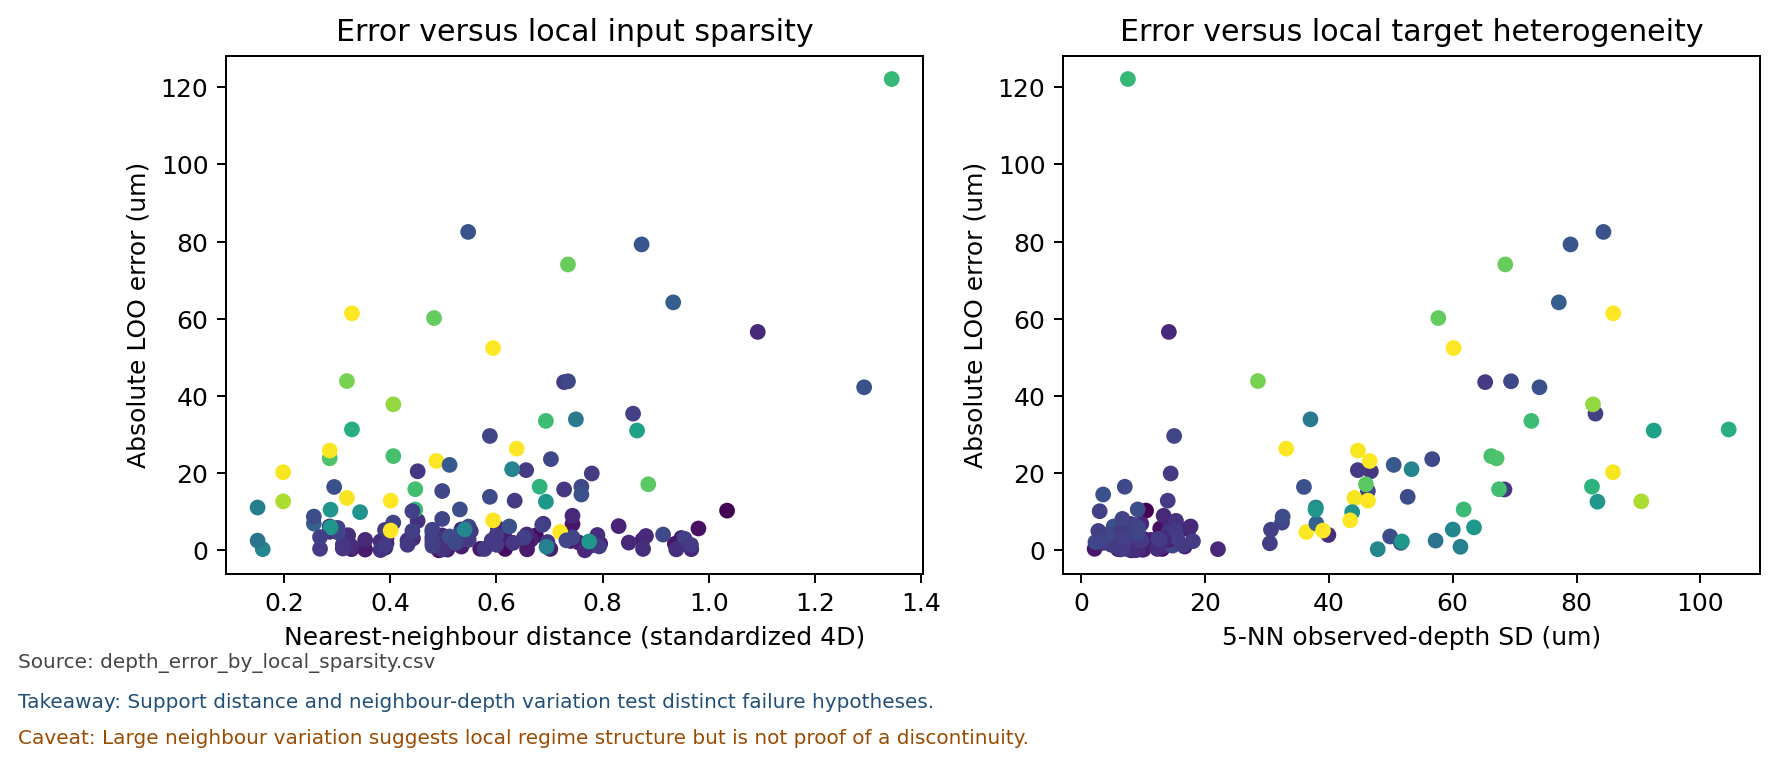

In [14]:
sparsity_summary = pd.read_csv(OUT / "depth_sparsity_association_summary.csv")
sparsity_rows = pd.read_csv(OUT / "depth_error_by_local_sparsity.csv")
rho_sparse, p_sparse = spearmanr(sparsity_rows["nearest_neighbor_distance_standardized"], sparsity_rows["primary_absolute_depth_error_um"])
rho_heterogeneity, p_heterogeneity = spearmanr(sparsity_rows["local_5nn_depth_std_um"], sparsity_rows["primary_absolute_depth_error_um"])
display(sparsity_summary)
display(pd.DataFrame([
    {"diagnostic": "nearest-neighbour distance", "recomputed_rho": rho_sparse, "recomputed_p": p_sparse},
    {"diagnostic": "local 5-NN depth SD", "recomputed_rho": rho_heterogeneity, "recomputed_p": p_heterogeneity},
]))
display(sparsity_rows.sort_values("primary_absolute_depth_error_um", ascending=False).head(15))
display(Image(filename=str(OUT / "figures" / "11_sparsity_and_local_heterogeneity.png")))

**What did we observe?** Nearest-neighbour sparsity has weak association with error (rho=0.047), whereas local 5-NN depth heterogeneity is much stronger (rho=0.582).

**What does it mean?** Simple marginal isolation is not the main signal; local response heterogeneity is more consistent with a transition/regime mechanism.

**Did Week 6 reproduce?** The broad depth directions survive even though local response predictability varies.

**What remains uncertain?** Neighbour heterogeneity is descriptive and does not prove a mathematical discontinuity.


## 15. Depth error versus old-design shift flags

**What are we doing?** We group new-data errors by Phase 1 descriptors of whether points lie beyond old marginal ranges or the old 4D hull.

**Why?** This asks whether newly explored physical regions are especially difficult.

**What question does it answer?** Are hard new-data responses enriched in old-domain expansion regions?

**What would be suspicious?** Calling these flags extrapolation for a GP trained entirely on new data.


In [15]:
old_shift = pd.read_csv(OUT / "depth_error_by_old_design_shift.csv")
display(old_shift)

,grouping,group,model,n,MAE,RMSE,median_absolute_error,q75_absolute_error,q90_absolute_error,q95_absolute_error,maximum_absolute_error,interpretation,spearman_rho_with_absolute_error,p_value
0,outside_any_week6_axis_range,False,matern32_learned_nugget,69,6.801366,12.611731,3.012959,6.208201,20.049550,32.239924,56.608978,old-design expansion descriptor; not a Phase 3...,NaN,NaN
1,outside_any_week6_axis_range,True,matern32_learned_nugget,95,15.667897,26.561359,6.201702,18.696620,43.196413,62.278388,122.115493,old-design expansion descriptor; not a Phase 3...,NaN,NaN
2,inside_week6_4d_convex_hull,False,matern32_learned_nugget,118,14.982710,25.313142,6.074786,19.236160,42.667067,60.380924,122.115493,old-design expansion descriptor; not a Phase 3...,NaN,NaN
3,inside_week6_4d_convex_hull,True,matern32_learned_nugget,46,4.125754,7.206265,2.651362,4.093309,7.279992,11.914835,35.431759,old-design expansion descriptor; not a Phase 3...,NaN,NaN
4,nearest_week6_scaled_euclidean_distance,continuous_spearman,matern32_learned_nugget,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,historical design-region descriptor; not new-d...,0.356843,0.000003


**What did we observe?** The table reports error by old-design membership without treating old data as training support.

**What does it mean?** These are descriptors of newly explored physical space, not Phase 3 GP extrapolation flags.

**Did Week 6 reproduce?** This extends the Week 6/new-data comparison with correct design-shift semantics.

**What remains uncertain?** Marginal-range and convex-hull membership do not fully measure local support density or regime structure.


## 16. Depth error versus Phase 2 quality and ambiguity flags

**What are we doing?** We join fixed residuals to Phase 2 window stability, depth ambiguity, recording cutoff, and geometric ratio diagnostics.

**Why?** Large errors could be amplified by uncertain target extraction rather than response complexity alone.

**What question does it answer?** Do hard cases overlap the existing target-quality warnings?

**What would be suspicious?** Relabelling targets, redefining T0, or converting diagnostic associations into exclusions.


In [16]:
quality = pd.read_csv(OUT / "depth_error_by_phase2_quality_flags.csv")
display(quality)

,grouping,group,model,n,MAE,RMSE,median_absolute_error,q75_absolute_error,q90_absolute_error,q95_absolute_error,maximum_absolute_error,diagnostic_type,spearman_rho_with_absolute_error,p_value
0,flag_primary_window_unstable_week6_rule,False,matern32_learned_nugget,157,10.861217,20.222608,4.003030,12.715849,27.680929,43.829805,122.115493,Phase 2 boolean quality/context flag,NaN,NaN
1,flag_primary_window_unstable_week6_rule,True,matern32_learned_nugget,7,36.076183,44.388126,31.341579,49.114338,71.564633,77.039876,82.515120,Phase 2 boolean quality/context flag,NaN,NaN
2,flag_depth_bounding_box_ambiguity_candidate,False,matern32_learned_nugget,158,12.061403,22.126687,4.206047,13.416126,33.675346,53.056312,122.115493,Phase 2 boolean quality/context flag,NaN,NaN
3,flag_depth_bounding_box_ambiguity_candidate,True,matern32_learned_nugget,6,8.673785,10.349176,7.865650,13.729472,15.916653,16.182512,16.448371,Phase 2 boolean quality/context flag,NaN,NaN
4,recording_ends_before_90pct_domain,False,matern32_learned_nugget,108,5.739748,10.346154,2.779239,5.868529,12.395779,20.957889,60.196273,Phase 2 boolean quality/context flag,NaN,NaN
5,recording_ends_before_90pct_domain,True,matern32_learned_nugget,56,23.890209,34.443863,15.143013,33.654702,59.018129,75.383501,122.115493,Phase 2 boolean quality/context flag,NaN,NaN
6,T0_depth_cv,continuous_spearman,matern32_learned_nugget,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Phase 2 continuous extraction/context diagnostic,0.172944,2.679219e-02
7,T0_sample_count,continuous_spearman,matern32_learned_nugget,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Phase 2 continuous extraction/context diagnostic,0.400169,1.102314e-07
8,max_depth_minus_G3_um,continuous_spearman,matern32_learned_nugget,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Phase 2 continuous extraction/context diagnostic,0.303704,7.706404e-05
9,max_depth_over_G3,continuous_spearman,matern32_learned_nugget,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Phase 2 continuous extraction/context diagnostic,0.179236,2.165204e-02


**What did we observe?** Some Phase 2 continuous quality indicators associate with error, but the evidence is not a clean single-flag explanation.

**What does it mean?** Target quality remains a plausible contributor inside a mixed diagnosis, not grounds for automatic exclusion.

**Did Week 6 reproduce?** T0 definitions and source labels remain unchanged.

**What remains uncertain?** Associations among depth scale, sample count, ratios, and physical regime can confound one-variable quality summaries.


## 17. Consensus hard-case physical review

**What are we doing?** We inspect a deterministic small set of top consensus errors plus well-predicted high-depth contrasts using existing raw traces.

**Why?** Aggregate tables cannot reveal whether individual trajectories look physically plausible or geometrically suspicious.

**What question does it answer?** What conservative mechanisms fit the most difficult cases?

**What would be suspicious?** Downloading hundreds of media files, changing ground truth, or excluding cases after visual review.


,experiment_name,partition,dataset_revision,P,VX,LS,ST,observed_depth_um,T0_depth_cv,T0_depth_valid_sample_count,...,top20_configuration_count,consensus_mean_residual_rank,consensus_max_residual_rank,consensus_hard_case,mean_absolute_residual_across_models,keyhole_segment_count,maximum_keyhole_segment_frames,keyhole_transient_by_sequence,keyhole_persistent_to_last_physical_frame,repeated_keyhole_episodes
144,P-408p574656479_VX-0p243547442248_LS-8p6553660...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,408.574656,0.243547,86.553661,318.028622,210.032800,0.146745,17110.0,...,3,1.000000,1.0,True,120.727597,1,45,False,True,False
93,P-293p648784497_VX-0p426690912013_LS-5p3394045...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,293.648784,0.426691,53.394046,351.677261,236.995550,0.093233,19034.0,...,3,2.666667,4.0,True,75.691296,1,114,False,True,False
87,P-277p972333632_VX-0p331196372511_LS-4p5620211...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,277.972334,0.331196,45.620212,324.411035,107.620500,0.226412,17697.0,...,3,3.666667,5.0,True,68.906681,1,84,False,True,False
132,P-379p421209359_VX-0p229921993373_LS-5p5753899...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,379.421209,0.229922,55.753899,334.989783,100.240900,0.139574,15848.0,...,3,5.000000,8.0,True,64.390751,1,33,True,False,False
149,P-422p617573631_VX-0p52186874631_LS-4p33544604...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,422.617574,0.521869,43.354460,334.849987,234.853600,0.095785,19611.0,...,3,5.333333,7.0,True,62.373808,1,174,False,True,False
155,P-438p134561959_VX-0p25154969533_LS-4p05773405...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,438.134562,0.251550,40.577341,340.985775,300.021900,0.066620,16047.0,...,3,5.666667,6.0,True,62.256845,1,63,False,True,False
117,P-360p567405001_VX-0p20359066256_LS-4p08177684...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,360.567405,0.203591,40.817768,337.353351,96.473320,0.201433,14304.0,...,3,6.000000,9.0,True,63.444358,1,31,True,False,False
116,P-358p08766286_VX-0p398145183006_LS-4p39068251...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,358.087663,0.398145,43.906825,301.093308,300.047350,0.012746,18640.0,...,3,7.666667,9.0,True,51.735587,1,120,False,True,False
77,P-260p125654688_VX-0p378472963537_LS-6p2127531...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,260.125655,0.378473,62.127532,359.026868,86.700545,0.001063,18604.0,...,3,9.000000,11.0,True,46.994871,0,0,False,False,False
154,P-435p358668153_VX-0p616312825798_LS-4p1230244...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,435.358668,0.616313,41.230244,330.720611,244.216800,0.148664,16579.0,...,3,10.333333,11.0,True,43.700914,1,193,False,True,False


,experiment_name,partition,dataset_revision,P,VX,LS,ST,observed_depth_um,T0_depth_cv,T0_depth_valid_sample_count,...,repeated_keyhole_episodes,nearest_neighbor_distance_standardized,local_5nn_depth_std_um,local_5nn_depth_range_um,selection_reason,diagnostic_review_label,diagnostic_review_evidence,existing_side_media_references,review_labels_are_ground_truth,simulation_excluded
0,P-408p574656479_VX-0p243547442248_LS-8p6553660...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,408.574656,0.243547,86.553661,318.028622,210.03280,0.146745,17110.0,...,False,1.344686,7.573296,19.514915,top consensus depth error,sparse-design / neighbour mismatch candidate,New-data 4D nearest-neighbour distance is in t...,P-408p574656479_VX-0p243547442248_LS-8p6553660...,False,False
1,P-293p648784497_VX-0p426690912013_LS-5p3394045...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,293.648784,0.426691,53.394046,351.677261,236.99555,0.093233,19034.0,...,False,0.734908,68.490598,135.442680,top consensus depth error,sparse-design / neighbour mismatch candidate,New-data 4D nearest-neighbour distance is in t...,P-293p648784497_VX-0p426690912013_LS-5p3394045...,False,False
2,P-277p972333632_VX-0p331196372511_LS-4p5620211...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,277.972334,0.331196,45.620212,324.411035,107.62050,0.226412,17697.0,...,False,0.933175,77.142188,176.968680,top consensus depth error,sparse-design / neighbour mismatch candidate,New-data 4D nearest-neighbour distance is in t...,P-277p972333632_VX-0p331196372511_LS-4p5620211...,False,False
3,P-379p421209359_VX-0p229921993373_LS-5p5753899...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,379.421209,0.229922,55.753899,334.989783,100.24090,0.139574,15848.0,...,False,0.873607,79.027220,199.902680,top consensus depth error,sparse-design / neighbour mismatch candidate,New-data 4D nearest-neighbour distance is in t...,P-379p421209359_VX-0p229921993373_LS-5p5753899...,False,False
4,P-422p617573631_VX-0p52186874631_LS-4p33544604...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,422.617574,0.521869,43.354460,334.849987,234.85360,0.095785,19611.0,...,False,0.482702,57.689740,129.136650,top consensus depth error,regime-transition candidate,Local depth heterogeneity is high and Keyhole ...,P-422p617573631_VX-0p52186874631_LS-4p33544604...,False,False
5,P-367p938083726_VX-0p695829187084_LS-4p3580026...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,367.938084,0.695829,43.580027,364.389585,152.05270,0.105898,14677.0,...,True,0.159939,47.900174,129.167685,well-predicted high-depth contrast,regime-transition candidate,Local depth heterogeneity is high and Keyhole ...,P-367p938083726_VX-0p695829187084_LS-4p3580026...,False,False
6,P-282p804328276_VX-0p543976889672_LS-5p2219725...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,282.804328,0.543977,52.219725,303.777238,146.44625,0.149796,18830.0,...,False,0.694436,61.257460,145.230280,well-predicted high-depth contrast,regime-transition candidate,Local depth heterogeneity is high and Keyhole ...,P-282p804328276_VX-0p543976889672_LS-5p2219725...,False,False
7,P-449p762375807_VX-0p721910835583_LS-4p0294971...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,449.762376,0.721911,40.294972,312.266646,172.24105,0.141880,14142.0,...,False,0.774790,51.809983,145.878240,well-predicted high-depth contrast,possible disconnected-component / bounding-box...,Phase 2 depth ambiguity flag is positive.,P-449p762375807_VX-0p721910835583_LS-4p0294971...,False,False


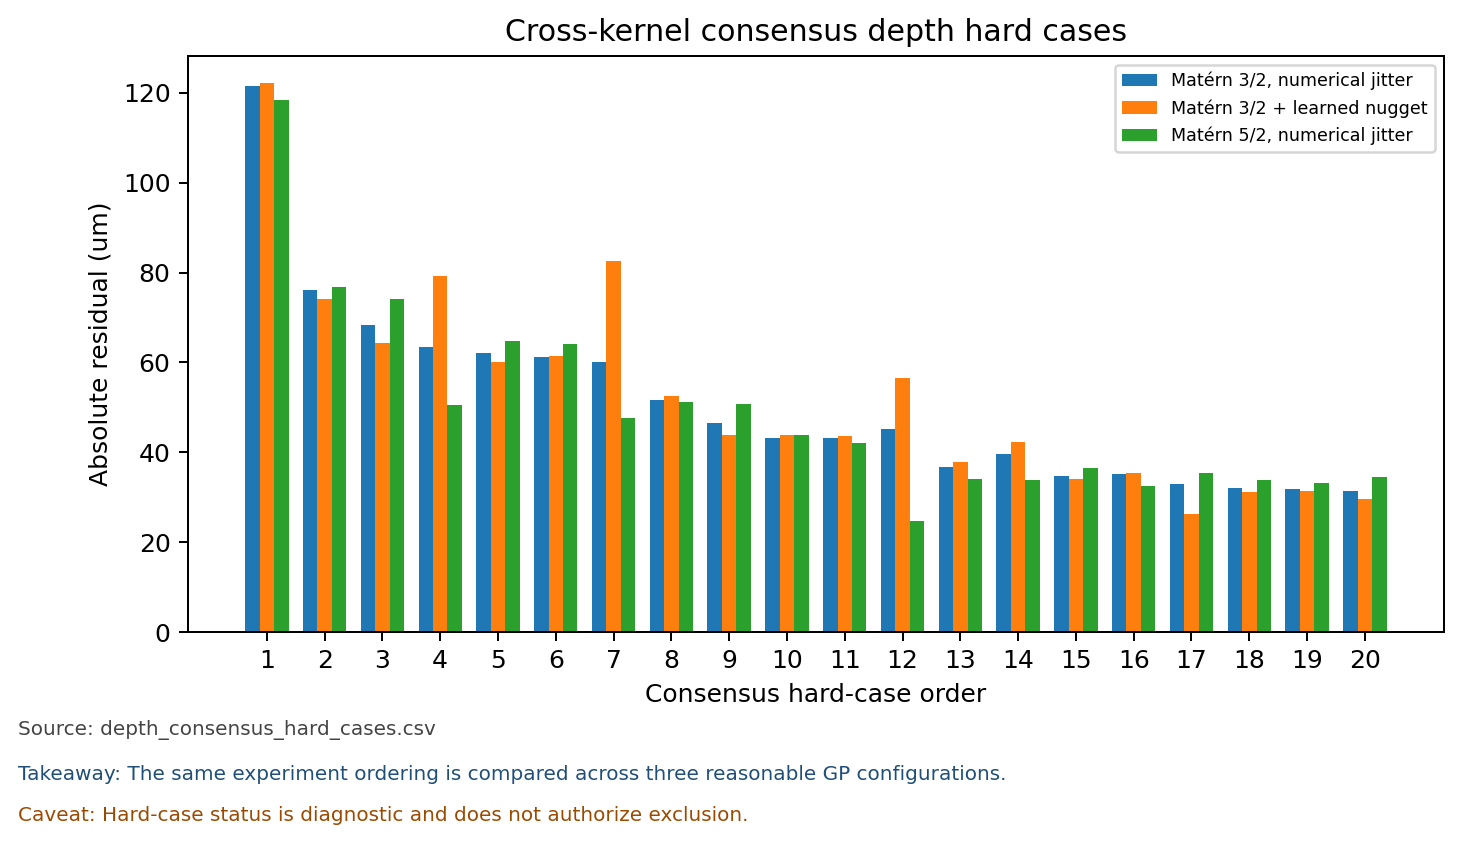

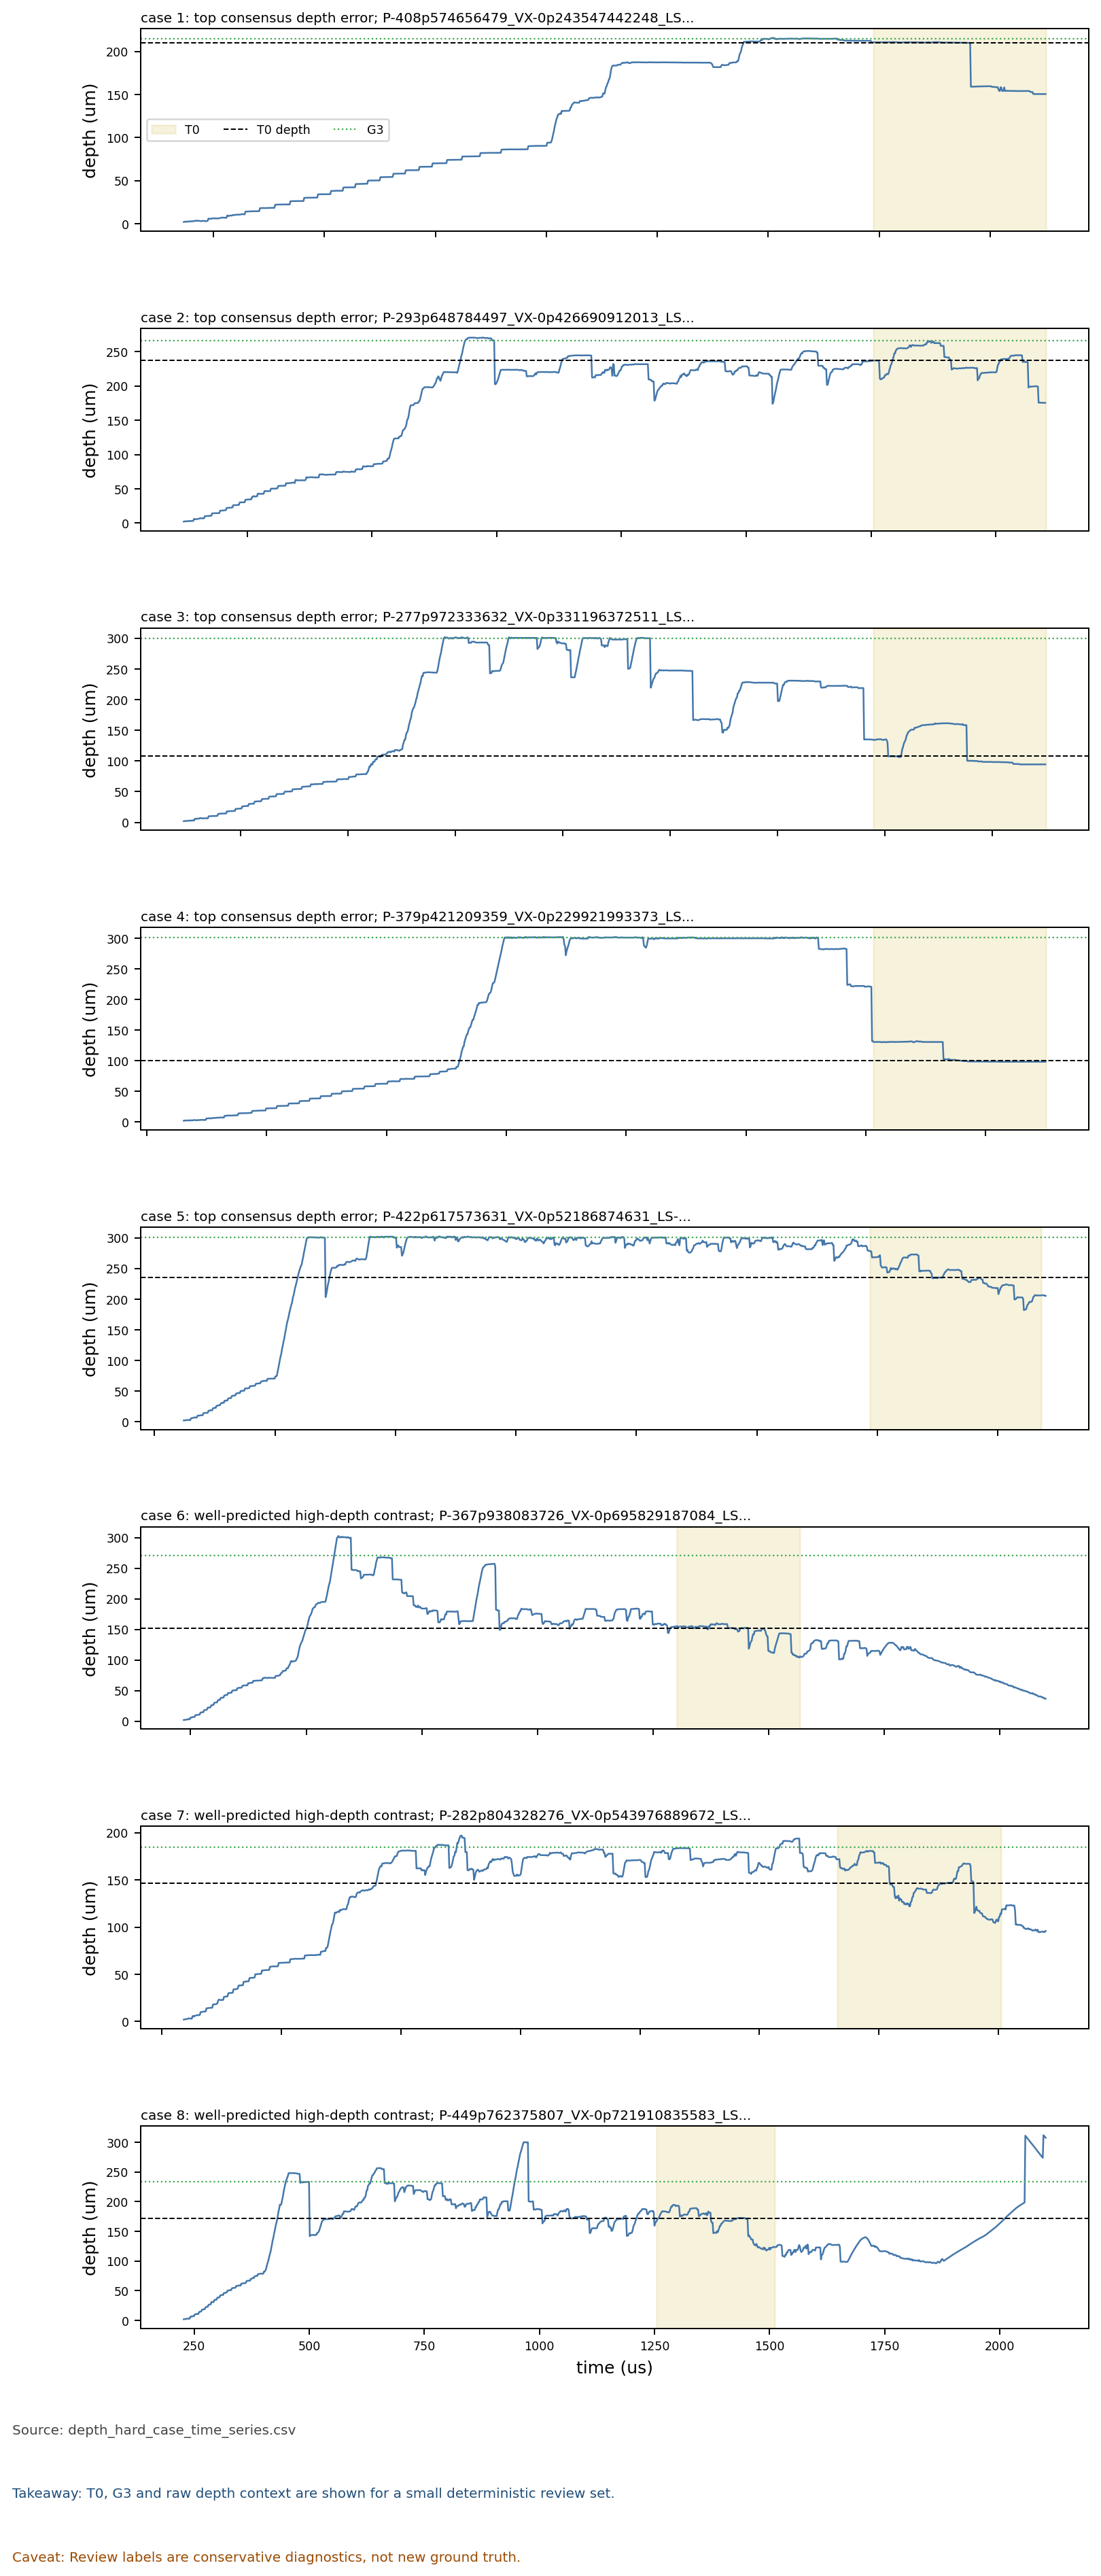

In [17]:
hard_cases = pd.read_csv(OUT / "depth_consensus_hard_cases.csv")
review = pd.read_csv(OUT / "depth_hard_case_review.csv")
display(hard_cases.sort_values("consensus_mean_residual_rank").head(12))
display(review)
display(Image(filename=str(OUT / "figures" / "12_consensus_hard_cases.png")))
display(Image(filename=str(OUT / "figures" / "13_hard_case_depth_traces.png")))

**What did we observe?** Twenty-one cases satisfy the cross-kernel consensus rule; the small raw-trace review assigns only conservative diagnostic labels.

**What does it mean?** Multiple reasonable Matérn configurations tend to fail on the same simulations, consistent with shared data/regime difficulty.

**Did Week 6 reproduce?** The main physical trend can reproduce even when a localized subset defeats smooth LOO prediction.

**What remains uncertain?** The small review cannot establish new ground-truth categories or justify exclusions.


## 18. Week 6 versus new-data physical-response stability

**What are we doing?** We synthesize historical and new-data evidence statement by statement.

**Why?** A thesis conclusion should distinguish reproduced, weakened, mixed, reversed, and unresolved claims.

**What question does it answer?** Which Week 6 physical-response statements survive the new simulation design?

**What would be suspicious?** Overclaiming weak ST evidence or turning a profile-dependent KE relationship into a universal rule.


,week6_statement,week6_evidence,new_data_evidence,status,causal_claim
0,LS has a material positive association with wi...,Spearman rho=0.469; standardized Ridge beta=0....,"rho=0.496 [0.355,0.612]; beta=0.714; GP median...",REPRODUCED,False
1,The KE-LS relationship is power-profile depend...,"Raw rho=0.223, Ridge beta=0.017, and q10/q50/q...",rho=-0.418; beta=0.101; GP median sensitivity=...,MIXED,False
2,Power is positively associated with T0 penetra...,Spearman rho=0.789; standardized Ridge beta=0....,Three-view consensus=REPRODUCED; rho=0.838; be...,REPRODUCED,False
3,Scan speed is negatively associated with T0 pe...,Spearman rho=-0.438; standardized Ridge beta=-...,Three-view consensus=REPRODUCED; rho=-0.445; b...,REPRODUCED,False
4,P-VX interactions shape the supported depth re...,Support-masked Week 6 P-VX GP surface showed n...,New-data surface has 85.4% supported grid cove...,REPRODUCED,False
5,Total height rises with P and falls with VX in...,Spearman P=0.801/VX=-0.310; Ridge P=0.793/VX=-...,P rho/beta/GP=0.778/0.544/0.325; VX=-0.479/-0....,REPRODUCED,False
6,ST associations were comparatively weak in the...,Across outputs |Spearman rho|<=0.200 and |Ridg...,New maximum |rho|=0.094; maximum |beta|=0.016....,REPRODUCED,False


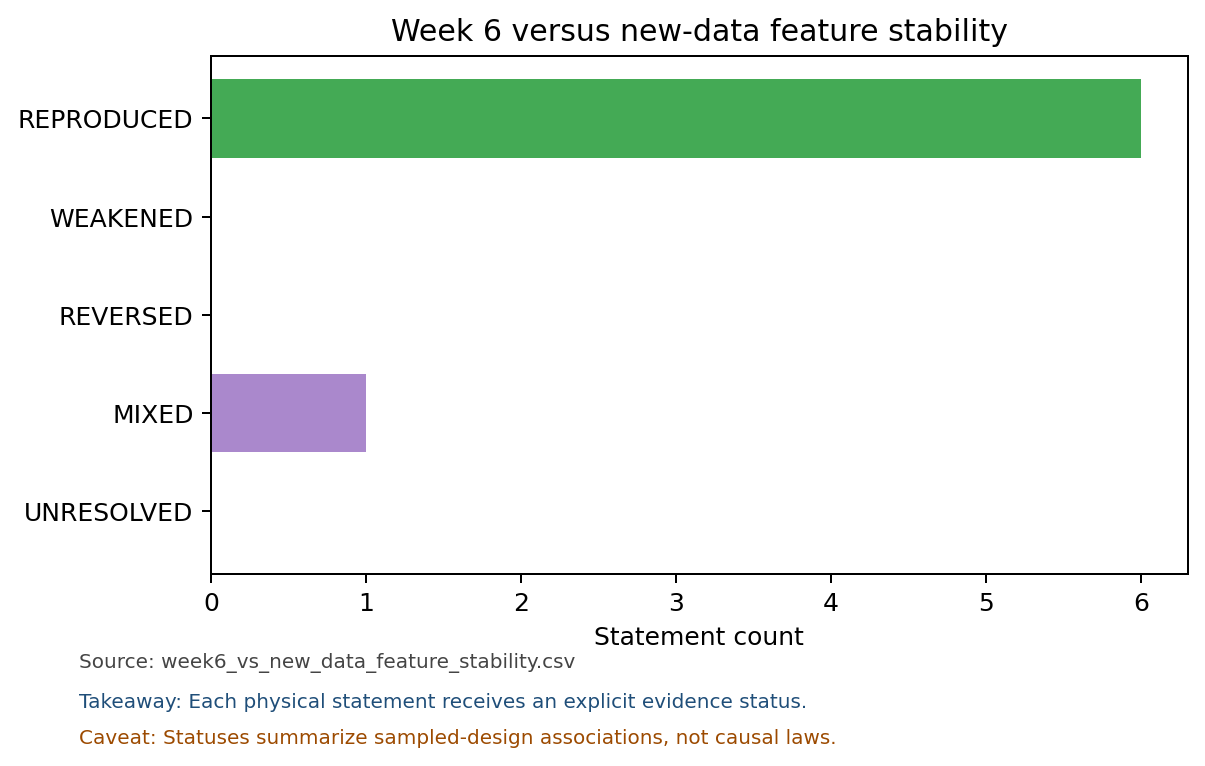

In [18]:
stability = pd.read_csv(OUT / "week6_vs_new_data_feature_stability.csv")
display(stability)
display(Image(filename=str(OUT / "figures" / "14_feature_stability_counts.png")))

**What did we observe?** Six statements are REPRODUCED and the qualified KE–LS statement is MIXED; no assessed statement is classified REVERSED.

**What does it mean?** The new design preserves the dominant physical-response picture while refining one interaction-dependent claim.

**Did Week 6 reproduce?** Width–LS, depth P/VX, P–VX surface structure, total-height pattern, and weak sampled-design ST association reproduce.

**What remains uncertain?** Weak observed ST association does not imply substrate temperature is physically unimportant.


## 19. Depth failure diagnosis

**What are we doing?** We answer D1–D10 and place the evidence into the predeclared model/design/regime/quality/mixed categories.

**Why?** Model changes should follow a mechanism-based diagnosis rather than discomfort with one metric.

**What question does it answer?** Does current evidence justify replacing the retained GP family?

**What would be suspicious?** Forcing a single cause or proposing a new model without resolving data/regime evidence.


,decision_id,question,answer,evidence,decision_category,model_changed
0,D1,Is relative depth RMSE broad or driven by a he...,heavy-error tail,Worst 5/10 contribute 48.2%/67.8% of total squ...,MIXED / UNRESOLVED,False
1,D2,Are large errors concentrated at high observed...,associated,"Spearman(|error|, observed depth)=0.607, p=7.2...",MIXED / UNRESOLVED,False
2,D3,Are they enriched in Keyhole-positive experime...,enriched,RMSE Keyhole true/false=32.931/9.788 um.,MIXED / UNRESOLVED,False
3,D4,Are they enriched when Keyhole timing is outsi...,see timing groups,Timing-specific fixed-residual group metrics a...,MIXED / UNRESOLVED,False
4,D5,Are they associated with local 4D design spars...,weak or absent,"rho=0.047, p=0.548.",MIXED / UNRESOLVED,False
5,D6,Are they associated with high local target het...,yes,"rho=0.582, p=2.95e-16.",MIXED / UNRESOLVED,False
6,D7,Are they associated with Phase 2 ambiguity or ...,possible,Strongest continuous quality association: T0_s...,MIXED / UNRESOLVED,False
7,D8,Do multiple GP kernels fail on the same simula...,yes,Common top-20 cases=17; three-way top-20 Jacca...,MIXED / UNRESOLVED,False
8,D9,Does the Week 6 P-positive/VX-negative depth r...,yes,P=REPRODUCED; VX=REPRODUCED.,MIXED / UNRESOLVED,False
9,D10,Does current evidence justify changing the GP ...,NO - retain for now,Phase 4 diagnoses fixed-model errors first; no...,MIXED / UNRESOLVED,False


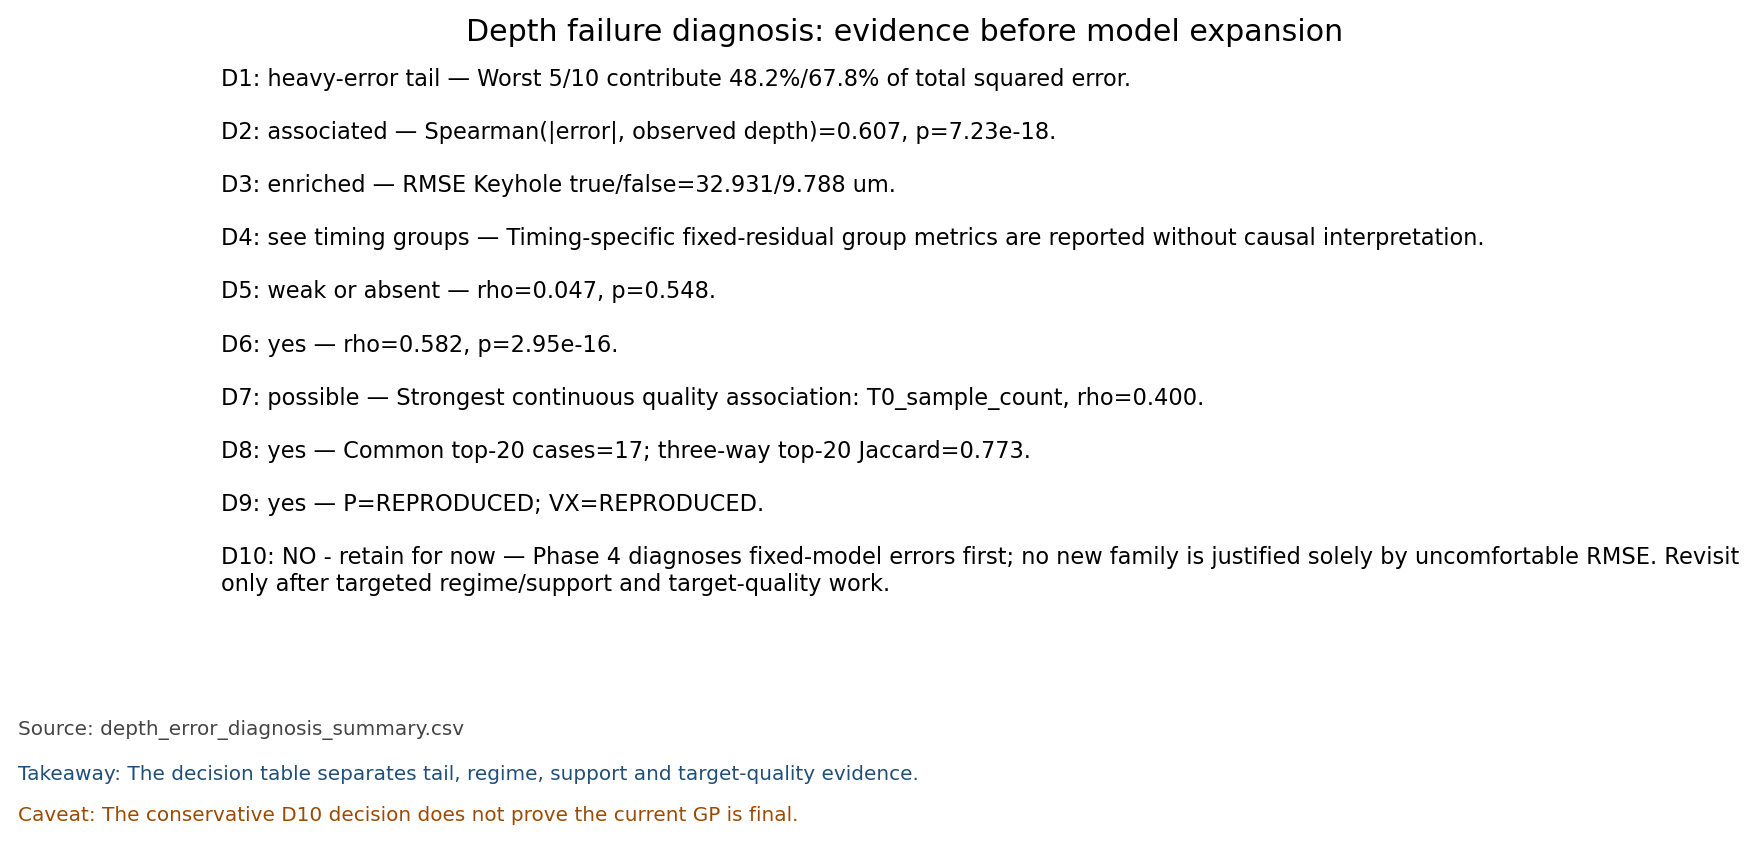

In [19]:
diagnosis = pd.read_csv(OUT / "depth_error_diagnosis_summary.csv")
display(diagnosis)
display(Image(filename=str(OUT / "figures" / "15_depth_diagnosis_summary.png")))

**What did we observe?** The overall category is MIXED / UNRESOLVED; neighbour distance is weak, local target heterogeneity and Keyhole/high-depth context are stronger, and kernels share many hard cases.

**What does it mean?** The evidence is more consistent with a mixed regime/target-quality problem than a demonstrated global model-family failure.

**Did Week 6 reproduce?** P-positive and VX-negative depth structure remains stable despite the large LOO tail.

**What remains uncertain?** Targeted support, regime, and raw-quality follow-up is needed before deciding whether a model-family change is warranted.


## 20. Validation and hard stop

**What are we doing?** We verify the automated safeguards, requirement checklist, notebook execution state, and every manifest hash.

**Why?** The scientific handoff must be reproducible and must stop before later thesis phases.

**What question does it answer?** Are all required artifacts internally consistent with the fixed scope?

**What would be suspicious?** A failed check, stored notebook error, missing artifact, hash mismatch, classifier, new kernel, or silent label/exclusion change.


In [20]:
validation = pd.read_csv(OUT / "validation_results.csv")
requirements = pd.read_csv(OUT / "requirement_checklist.csv")
manifest = pd.read_csv(OUT / "output_manifest.csv")

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

manifest_check = manifest.assign(
    exists=manifest["relative_path"].map(lambda name: (OUT / name).is_file()),
    current_sha256=manifest["relative_path"].map(lambda name: sha256(OUT / name)),
)
manifest_check["hash_matches"] = manifest_check["sha256"].eq(manifest_check["current_sha256"])
display(validation)
display(requirements)
display(manifest_check.groupby(["exists", "hash_matches"]).size().rename("files").reset_index())
assert set(validation["status"]) == {"PASS"}
assert set(requirements["status"]) == {"PASS"}
assert manifest_check[["exists", "hash_matches"]].all().all()
assert summary["scope"]["classifier_fitted"] is False
assert summary["scope"]["active_learning"] is False
assert summary["scope"]["level_set_estimation"] is False
print("HARD STOP CONFIRMED — Phase 4 outputs only; no later-phase modelling was performed.")

,validation_id,requirement,status,evidence
0,V01,Phase 4 parent is exact committed Phase 3 SHA,PASS,1118d30f3199a97b9836591f8fdea75b46dfac0d
1,V02,Dataset revision is exact immutable sph_v2 rev...,PASS,d69dac5bda8b622bc0de316b112815c6056c06ec
2,V03,Primary feature population is new-data only,PASS,"audit=165; table_counts={width:164, depth:164,..."
3,V04,Eligibility comes from corrected Phase 2 readi...,PASS,per-target eligibility source fields retained
4,V05,No hard-coded experiment exclusion is used,PASS,depth rows=164
5,V06,Historical Week 6 definitions are traced to ex...,PASS,traceability rows=8
6,V07,Spearman results reconcile with raw target tables,PASS,rows=16
7,V08,Standardized Ridge uses Week 6 alpha grid and ...,PASS,"alpha_grid=(1e-06, 1e-05, 0.0001, 0.001, 0.01,..."
8,V09,Controlled curves use declared full-data inter...,PASS,rows=1818
9,V10,GP sensitivity calculations apply range and su...,PASS,rows=2624


,requirement_id,requirement,status,validation_ids
0,P4-01,Exact Phase 3 parent and immutable dataset pro...,PASS,V01;V02
1,P4-02,Complete 165-row audit interface with machine-...,PASS,V03;V04;V05
2,P4-03,Executable Week 6 feature-analysis traceability,PASS,V06
3,P4-04,All 16 Spearman associations with simulation b...,PASS,V07
4,P4-05,Standardized Week 6 Ridge coefficient replication,PASS,V08
5,P4-06,Controlled full-data GP curves inside observed...,PASS,V09
6,P4-07,Standardized local GP sensitivities with guards,PASS,V10
7,P4-08,Support-masked depth and total-height P-VX sur...,PASS,V09;V23
8,P4-09,Phase 3 LOO depth errors reused for three GP c...,PASS,V11;V12
9,P4-10,Error concentration and consensus cases retain...,PASS,V13;V20


,exists,hash_matches,files
0,True,True,101


HARD STOP CONFIRMED — Phase 4 outputs only; no later-phase modelling was performed.


**What did we observe?** The pre-notebook run recorded 24/24 validation checks, 20/20 requirements, and 15 figures; the final validator refreshes notebook-specific checks after execution.

**What does it mean?** The artifact set is internally consistent and explicitly bounded to Phase 4.

**Did Week 6 reproduce?** The Week 6 replication and Phase 3 LOO reuse are both traceable without changing their source artifacts.

**What remains uncertain?** Later classifier, target-selection, active-learning, level-set, and alternative-model decisions remain intentionally deferred.
